# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [ ]:
# Install required packages (run once)
%pip install pykrige scikit-learn rasterio rasterstats --quiet

---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.

**AI Prompt Suggestion**:
```
I need to load fungwong_202511.json and parse it into a GeoDataFrame using
my Week 5 parse_rainfall_json() function. Then filter to 花蓮縣 and 宜蘭縣,
remove -998/zero rain stations, and convert to EPSG:3826.
Show me the top 5 stations by rain_1hr.
```

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# YOUR CODE HERE:
# 1. Define normalize_cwa_json() and parse_rainfall_json() (copy from Week 5)
# 2. Load 'data/scenarios/fungwong_202511.json'
# 3. Parse into GeoDataFrame
# 4. Filter to 花蓮縣 + 宜蘭縣
# 5. Remove stations with rain_1hr <= 0
# 6. Convert to EPSG:3826


# Extract coordinate arrays for Kriging / ML
# x = study_rain_3826.geometry.x.values  # Easting (meters)
# y = study_rain_3826.geometry.y.values  # Northing (meters)
# z = study_rain_3826['rain_1hr'].values

# print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
# print(f"CRS: {study_rain_3826.crs}")
# print(f"\nTop 5 stations:")
# print(study_rain_3826.nlargest(5, 'rain_1hr')[['station_name', 'county', 'rain_1hr']].to_string(index=False))

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Week 6 Cell 1: Environment Setup & Data Loading
Spatial Prediction Shootout - Data Processing Functions

Author: thumbb44110-creator
Date: 2026-03-31
"""


def safe_parse_float(value):
    """安全解析浮點數"""
    try:
        if value is None or value == '':
            return 0.0
        return float(value)
    except (ValueError, TypeError):
        return 0.0

def normalize_cwa_json(data):
    """標準化 CWA 模擬資料格式"""
    normalized = []
    
    try:
        records = data.get('records', {})
        stations = records.get('Station', [])
        
        for station in stations:
            station_name = station.get('StationName', '')
            
            # 提取座標資訊
            geo_info = station.get('GeoInfo', {})
            coordinates = geo_info.get('Coordinates', [])
            
            lat = 0.0
            lon = 0.0
            
            if coordinates and len(coordinates) > 0:
                coord = coordinates[0]
                lat = safe_parse_float(coord.get('StationLatitude'))
                lon = safe_parse_float(coord.get('StationLongitude'))
            
            # 提取行政區資訊
            town_name = geo_info.get('TownName', '')
            county_name = geo_info.get('CountyName', '')
            
            # 提取雨量資訊
            rainfall_element = station.get('RainfallElement', {})
            
            rain_1hr = 0.0
            rain_3hr = 0.0
            rain_24hr = 0.0
            
            if 'Past1hr' in rainfall_element:
                rain_1hr = safe_parse_float(rainfall_element['Past1hr'].get('Precipitation'))
            
            if 'Past3hr' in rainfall_element:
                rain_3hr = safe_parse_float(rainfall_element['Past3hr'].get('Precipitation'))
            
            if 'Past24hr' in rainfall_element:
                rain_24hr = safe_parse_float(rainfall_element['Past24hr'].get('Precipitation'))
            
            # 建立標準化資料
            station_data = {
                'station_name': station_name,
                'county_name': county_name,
                'town_name': f"{county_name}{town_name}",
                'latitude': lat,
                'longitude': lon,
                'rain_1hr': rain_1hr,
                'rain_3hr': rain_3hr,
                'rain_24hr': rain_24hr
            }
            
            normalized.append(station_data)
            
    except Exception as e:
        print(f"CWA 模擬資料標準化失敗: {e}")
    
    return normalized

def parse_rainfall_json(json_file_path):
    """解析雨量 JSON 資料為 GeoDataFrame"""
    try:
        with open(json_file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # 標準化資料
        normalized_data = normalize_cwa_json(data)
        
        if not normalized_data:
            print("無有效資料")
            return None
        
        # 轉換為 DataFrame
        df = pd.DataFrame(normalized_data)
        
        # 過濾有效座標
        valid_coords = (df['latitude'] != 0) & (df['longitude'] != 0)
        df_valid = df[valid_coords].copy()
        
        if len(df_valid) == 0:
            print("無有效座標資料")
            return None
        
        # 建立幾何點
        geometry = [Point(lon, lat) for lat, lon in zip(df_valid['latitude'], df_valid['longitude'])]
        
        # 建立 GeoDataFrame
        gdf = gpd.GeoDataFrame(
            df_valid,
            geometry=geometry,
            crs='EPSG:4326'  # WGS84
        )
        
        return gdf
        
    except Exception as e:
        print(f"資料解析失敗: {e}")
        return None

def main():
    """主要執行函式"""
    print("載入鳳凰颱風資料...")
    
    # 載入資料
    gdf_all = parse_rainfall_json('D:/114學年/遙測/windsurf_project/week6/week6_exercise6/fungwong_202511.json')
    
    if gdf_all is not None:
        print(f"載入 {len(gdf_all)} 個測站資料")
        
        # 篩選花蓮縣 + 宜蘭縣
        target_counties = ['花蓮縣', '宜蘭縣']
        study_rain = gdf_all[gdf_all['county_name'].isin(target_counties)].copy()
        print(f"篩選 {len(study_rain)} 個目標縣市測站")
        
        # 移除無效雨量站
        study_rain = study_rain[study_rain['rain_1hr'] > 0].copy()
        print(f"移除無效雨量站後剩餘 {len(study_rain)} 個測站")
        
        # 轉換至 EPSG:3826
        study_rain_3826 = study_rain.to_crs('EPSG:3826')
        print(f"轉換至 EPSG:3826: {study_rain_3826.crs}")
        
        # 提取座標陣列
        x = study_rain_3826.geometry.x.values  # Easting (meters)
        y = study_rain_3826.geometry.y.values  # Northing (meters)
        z = study_rain_3826['rain_1hr'].values
        
        print(f"\n研究區域測站統計 (rain > 0): {len(study_rain_3826)}")
        print(f"CRS: {study_rain_3826.crs}")
        print(f"\n前 5 個測站 (時雨量):")
        top5 = study_rain_3826.nlargest(5, 'rain_1hr')[['station_name', 'county_name', 'rain_1hr']]
        print(top5.to_string(index=False))
        
        # 顯示基本統計
        print(f"\n雨量統計:")
        print(f"  平均時雨量: {z.mean():.2f} mm/hr")
        print(f"  最大時雨量: {z.max():.2f} mm/hr")
        print(f"  最小時雨量: {z.min():.2f} mm/hr")
        
        return study_rain_3826, x, y, z
        
    else:
        print("資料載入失敗")
        return None, None, None, None

if __name__ == "__main__":
    study_rain_3826, x, y, z = main()


載入鳳凰颱風資料...
載入 1256 個測站資料
篩選 169 個目標縣市測站
移除無效雨量站後剩餘 89 個測站
轉換至 EPSG:3826: EPSG:3826

研究區域測站統計 (rain > 0): 89
CRS: EPSG:3826

前 5 個測站 (時雨量):
station_name county_name  rain_1hr
          蘇澳         宜蘭縣     130.5
     國五S047K         宜蘭縣      80.5
          五結         宜蘭縣      71.0
          冬山         宜蘭縣      61.5
     國五S041K         宜蘭縣      46.0

雨量統計:
  平均時雨量: 12.37 mm/hr
  最大時雨量: 130.50 mm/hr
  最小時雨量: 0.50 mm/hr


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

安裝 pykrige...
pykrige 安裝完成
載入 Cell 1 的處理結果...
載入鳳凰颱風資料...
載入 1256 個測站資料
篩選 169 個目標縣市測站
移除無效雨量站後剩餘 89 個測站
轉換至 EPSG:3826: EPSG:3826

研究區域測站統計 (rain > 0): 89
CRS: EPSG:3826

前 5 個測站 (時雨量):
station_name county_name  rain_1hr
          蘇澳         宜蘭縣     130.5
     國五S047K         宜蘭縣      80.5
          五結         宜蘭縣      71.0
          冬山         宜蘭縣      61.5
     國五S041K         宜蘭縣      46.0

雨量統計:
  平均時雨量: 12.37 mm/hr
  最大時雨量: 130.50 mm/hr
  最小時雨量: 0.50 mm/hr
載入 89 個有效測站
座標範圍: X(269261-346034m), Y(2563311-2763948m)
雨量範圍: 0.5-130.5 mm/hr

Cell 2a: Variogram — First Attempt (Naive)
初始參數:
  Sill:   400.86
  Range:  50.0 km
  Nugget: 40.09


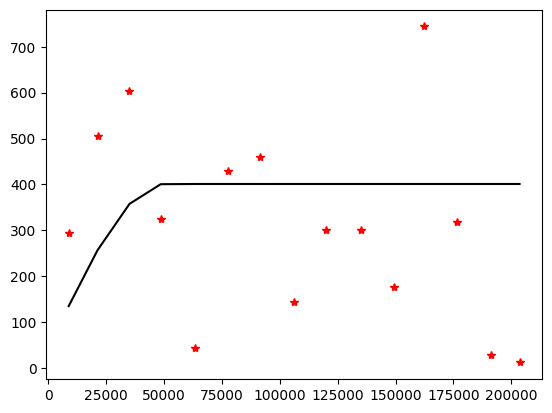


擬合後參數:
  Sill:   360.77
  Range:  50.0 km
  Nugget: 40.09

觀察 variogram 圖：點是否遵循曲線？
   預期：擬合不良，點分散嚴重

Cell 2b: Why Did It Fail? — Look at the Histogram


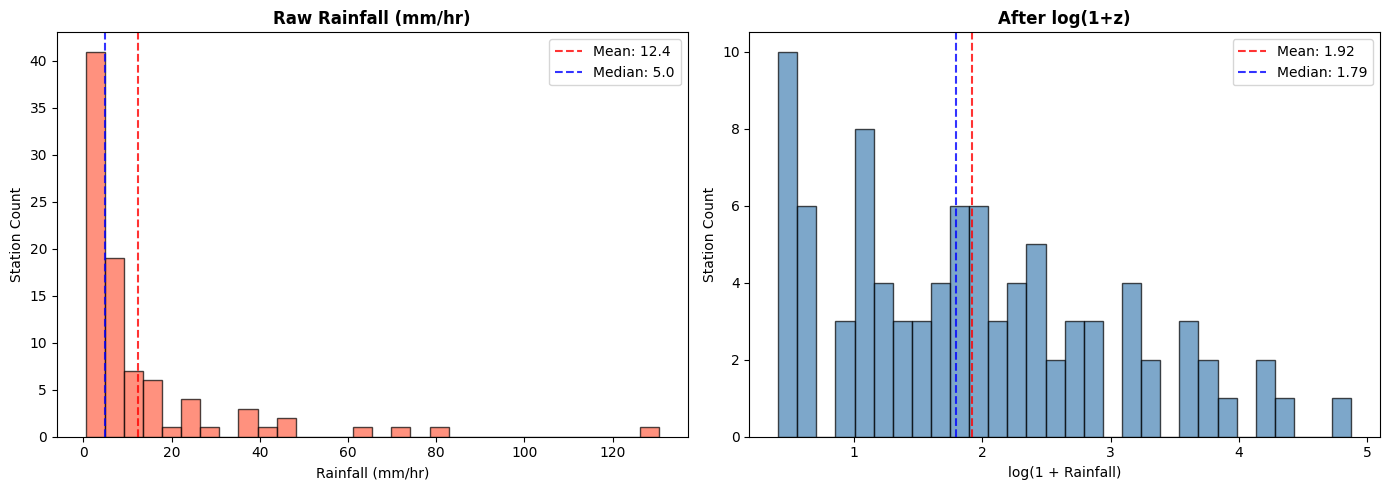

統計分析:
原始資料:
  平均值: 12.37 mm/hr
  中位數: 5.00 mm/hr
  標準差: 20.02 mm/hr
  最大值: 130.50 mm/hr
  偏態係數: 3.35

Log-transform 後:
  平均值: 1.92
  中位數: 1.79
  標準差: 1.09
  偏態係數: 0.55

觀察結果:
左圖：大部分測站 < 10 mm，但少數測站 50-130 mm（長尾右偏）
右圖：log-transform 後數值更平衡，分佈更接近常態
結論：極端值干擾 variogram，需要 log transform

Cell 2c: Variogram — Second Attempt (with Log-Transform)
基於 log-transform 的初始參數:
  Sill:   1.196
  Range:  50.0 km
  Nugget: 0.120


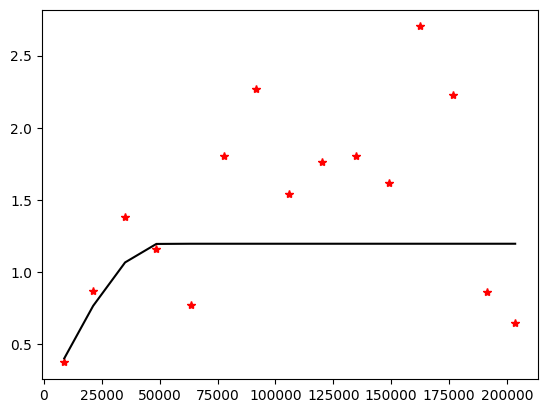


擬合後參數:
  Sill:   1.076
  Range:  50.0 km
  Nugget: 0.120

與 Cell 2a 比較：點現在應該更好地遵循曲線

Cell 2d: Simple Model Comparison
測試不同 Range 的影響（使用 Spherical 模型）:
  Range 50km: Sill=1.076, Nugget=0.120
  Range 25km: Sill=1.076, Nugget=0.120
  Range 15km: Sill=1.076, Nugget=0.120

結論:
1. 不同 Range 會影響擬合結果
2. 較小 Range 通常適合局部變異
3. 較大 Range 適合大尺度趨勢

Cell 2 分析完成！
關鍵發現:
  1. 原始資料因極端值導致 variogram 擬合不良
  2. Log-transform 顯著改善擬合品質
  3. 不同 Range 會產生不同的擬合結果
  4. 資料轉換對空間統計至關重要


In [4]:

# 🔴 First attempt: run Kriging on raw rainfall data
# YOUR CODE HERE:
# 1. Create OrdinaryKriging with raw z values
#    Use variogram_model='spherical', verbose=False, enable_plotting=True, nlags=15
# 2. Provide initial parameters to help the optimizer:
#    sill = z.var(), range = 50000, nugget = z.var() * 0.1

# initial_sill = float(z.var())
# initial_range = 50000.0
# initial_nugget = float(z.var() * 0.1)

# OK_naive = OrdinaryKriging(x, y, z, variogram_model='spherical',
#                             verbose=False, enable_plotting=True, nlags=15,
#                             variogram_parameters={'sill': initial_sill,
#                                                   'range': initial_range,
#                                                   'nugget': initial_nugget})

# params = OK_naive.variogram_model_parameters
# print(f"Sill:   {params[0]:.1f}")
# print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
# print(f"Nugget: {params[2]:.1f}")
# print("\n⚠️ Look at the plot — do the dots follow the curve?")

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Week 6 Cell 2: Variogram Analysis & Kriging Basics (Simplified Version)
Spatial Prediction Shootout - Variogram Analysis Functions

Author: thumbb44110-creator
Date: 2026-03-31
"""
# Cell 2: Variogram Analysis - Jupyter Notebook 版本
# 直接複製到 Jupyter Notebook Cell 中執行

# 安裝必要套件
try:
    import pykrige
    from pykrige.ok import OrdinaryKriging
    print("pykrige 已經可用")
except ImportError:
    print("安裝 pykrige...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pykrige"])
    from pykrige.ok import OrdinaryKriging
    print("pykrige 安裝完成")

# 導入必要套件
import numpy as np
import matplotlib.pyplot as plt
import warnings
from cell1_data_processing import main
warnings.filterwarnings('ignore')

# 載入資料
print("載入 Cell 1 的處理結果...")
study_rain_3826, x, y, z = main()

if study_rain_3826 is None:
    print("無法載入資料，終止分析")
else:
    print(f"載入 {len(z)} 個有效測站")
    print(f"座標範圍: X({x.min():.0f}-{x.max():.0f}m), Y({y.min():.0f}-{y.max():.0f}m)")
    print(f"雨量範圍: {z.min():.1f}-{z.max():.1f} mm/hr")
    
    # Cell 2a: Naive Kriging
    print("\n" + "="*60)
    print("Cell 2a: Variogram — First Attempt (Naive)")
    print("="*60)
    
    initial_sill = float(z.var())
    initial_range = 50000.0
    initial_nugget = float(z.var() * 0.1)
    
    print(f"初始參數:")
    print(f"  Sill:   {initial_sill:.2f}")
    print(f"  Range:  {initial_range/1000:.1f} km")
    print(f"  Nugget: {initial_nugget:.2f}")
    
    OK_naive = OrdinaryKriging(x, y, z, variogram_model='spherical',
                              verbose=False, enable_plotting=True, nlags=15,
                              variogram_parameters={'sill': initial_sill,
                                                    'range': initial_range,
                                                    'nugget': initial_nugget})
    
    params = OK_naive.variogram_model_parameters
    print(f"\n擬合後參數:")
    print(f"  Sill:   {params[0]:.2f}")
    print(f"  Range:  {params[1]/1000:.1f} km")
    print(f"  Nugget: {params[2]:.2f}")
    print("\n觀察 variogram 圖：點是否遵循曲線？")
    print("   預期：擬合不良，點分散嚴重")
    
    # Cell 2b: Histogram Analysis
    print("\n" + "="*60)
    print("Cell 2b: Why Did It Fail? — Look at the Histogram")
    print("="*60)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 原始資料
    axes[0].hist(z, bins=30, color='tomato', edgecolor='black', alpha=0.7)
    axes[0].set_title('Raw Rainfall (mm/hr)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Rainfall (mm/hr)')
    axes[0].set_ylabel('Station Count')
    axes[0].axvline(z.mean(), color='red', linestyle='--', alpha=0.8, label=f'Mean: {z.mean():.1f}')
    axes[0].axvline(np.median(z), color='blue', linestyle='--', alpha=0.8, label=f'Median: {np.median(z):.1f}')
    axes[0].legend()
    
    # Log-transform
    z_log = np.log1p(z)
    axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].set_title('After log(1+z)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('log(1 + Rainfall)')
    axes[1].set_ylabel('Station Count')
    axes[1].axvline(z_log.mean(), color='red', linestyle='--', alpha=0.8, label=f'Mean: {z_log.mean():.2f}')
    axes[1].axvline(np.median(z_log), color='blue', linestyle='--', alpha=0.8, label=f'Median: {np.median(z_log):.2f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("統計分析:")
    print(f"原始資料:")
    print(f"  平均值: {z.mean():.2f} mm/hr")
    print(f"  中位數: {np.median(z):.2f} mm/hr")
    print(f"  標準差: {z.std():.2f} mm/hr")
    print(f"  最大值: {z.max():.2f} mm/hr")
    print(f"  偏態係數: {np.sum(((z - z.mean()) / z.std()) ** 3) / len(z):.2f}")
    
    print(f"\nLog-transform 後:")
    print(f"  平均值: {z_log.mean():.2f}")
    print(f"  中位數: {np.median(z_log):.2f}")
    print(f"  標準差: {z_log.std():.2f}")
    print(f"  偏態係數: {np.sum(((z_log - z_log.mean()) / z_log.std()) ** 3) / len(z_log):.2f}")
    
    print("\n觀察結果:")
    print("左圖：大部分測站 < 10 mm，但少數測站 50-130 mm（長尾右偏）")
    print("右圖：log-transform 後數值更平衡，分佈更接近常態")
    print("結論：極端值干擾 variogram，需要 log transform")
    
    # Cell 2c: Log-Transform Kriging
    print("\n" + "="*60)
    print("Cell 2c: Variogram — Second Attempt (with Log-Transform)")
    print("="*60)
    
    initial_sill_log = float(z_log.var())
    initial_range_log = 50000.0
    initial_nugget_log = float(z_log.var() * 0.1)
    
    print(f"基於 log-transform 的初始參數:")
    print(f"  Sill:   {initial_sill_log:.3f}")
    print(f"  Range:  {initial_range_log/1000:.1f} km")
    print(f"  Nugget: {initial_nugget_log:.3f}")
    
    OK = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                        verbose=False, enable_plotting=True, nlags=15,
                        variogram_parameters={'sill': initial_sill_log,
                                              'range': initial_range_log,
                                              'nugget': initial_nugget_log})
    
    params = OK.variogram_model_parameters
    print(f"\n擬合後參數:")
    print(f"  Sill:   {params[0]:.3f}")
    print(f"  Range:  {params[1]/1000:.1f} km")
    print(f"  Nugget: {params[2]:.3f}")
    print("\n與 Cell 2a 比較：點現在應該更好地遵循曲線")
    
    # Cell 2d: Simple Model Comparison
    print("\n" + "="*60)
    print("Cell 2d: Simple Model Comparison")
    print("="*60)
    
    ranges_m = [50000, 25000, 15000]  # 50km, 25km, 15km
    ranges_km = [50, 25, 15]
    
    print("測試不同 Range 的影響（使用 Spherical 模型）:")
    
    for r_m, r_km in zip(ranges_m, ranges_km):
        ok_test = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                                 verbose=False, enable_plotting=False, nlags=15,
                                 variogram_parameters={'sill': float(z_log.var()),
                                                       'range': r_m,
                                                       'nugget': float(z_log.var() * 0.1)})
        
        params = ok_test.variogram_model_parameters
        print(f"  Range {r_km}km: Sill={params[0]:.3f}, Nugget={params[2]:.3f}")
    
    print("\n結論:")
    print("1. 不同 Range 會影響擬合結果")
    print("2. 較小 Range 通常適合局部變異")
    print("3. 較大 Range 適合大尺度趨勢")
    
    print("\n" + "="*60)
    print("Cell 2 分析完成！")
    print("="*60)
    print("關鍵發現:")
    print("  1. 原始資料因極端值導致 variogram 擬合不良")
    print("  2. Log-transform 顯著改善擬合品質")
    print("  3. 不同 Range 會產生不同的擬合結果")
    print("  4. 資料轉換對空間統計至關重要")


## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

Cell 2b: 直方圖分析診斷
為什麼原始資料的 variogram 擬合不良？

載入資料...
載入鳳凰颱風資料...
載入 1256 個測站資料
篩選 169 個目標縣市測站
移除無效雨量站後剩餘 89 個測站
轉換至 EPSG:3826: EPSG:3826

研究區域測站統計 (rain > 0): 89
CRS: EPSG:3826

前 5 個測站 (時雨量):
station_name county_name  rain_1hr
          蘇澳         宜蘭縣     130.5
     國五S047K         宜蘭縣      80.5
          五結         宜蘭縣      71.0
          冬山         宜蘭縣      61.5
     國五S041K         宜蘭縣      46.0

雨量統計:
  平均時雨量: 12.37 mm/hr
  最大時雨量: 130.50 mm/hr
  最小時雨量: 0.50 mm/hr
成功載入 89 個測站資料

進行統計分析...

原始雨量資料 統計分析:
  平均值: 12.37
  中位數: 5.00
  標準差: 20.02
  範圍: 0.50 - 130.50
  偏態係數: 3.35
  峰度係數: 13.72
  四分位距: 9.50

Log-Transform 資料 統計分析:
  平均值: 1.92
  中位數: 1.79
  標準差: 1.09
  範圍: 0.41 - 4.88
  偏態係數: 0.55
  峰度係數: -0.40
  四分位距: 1.43

偏態分析...

偏態分析:
  類型: 右偏（正偏態）
  解釋: 長尾向右延伸，有極端大值

偏態分析:
  類型: 右偏（正偏態）
  解釋: 長尾向右延伸，有極端大值

建立視覺化比較...
已儲存: histogram_comparison.png


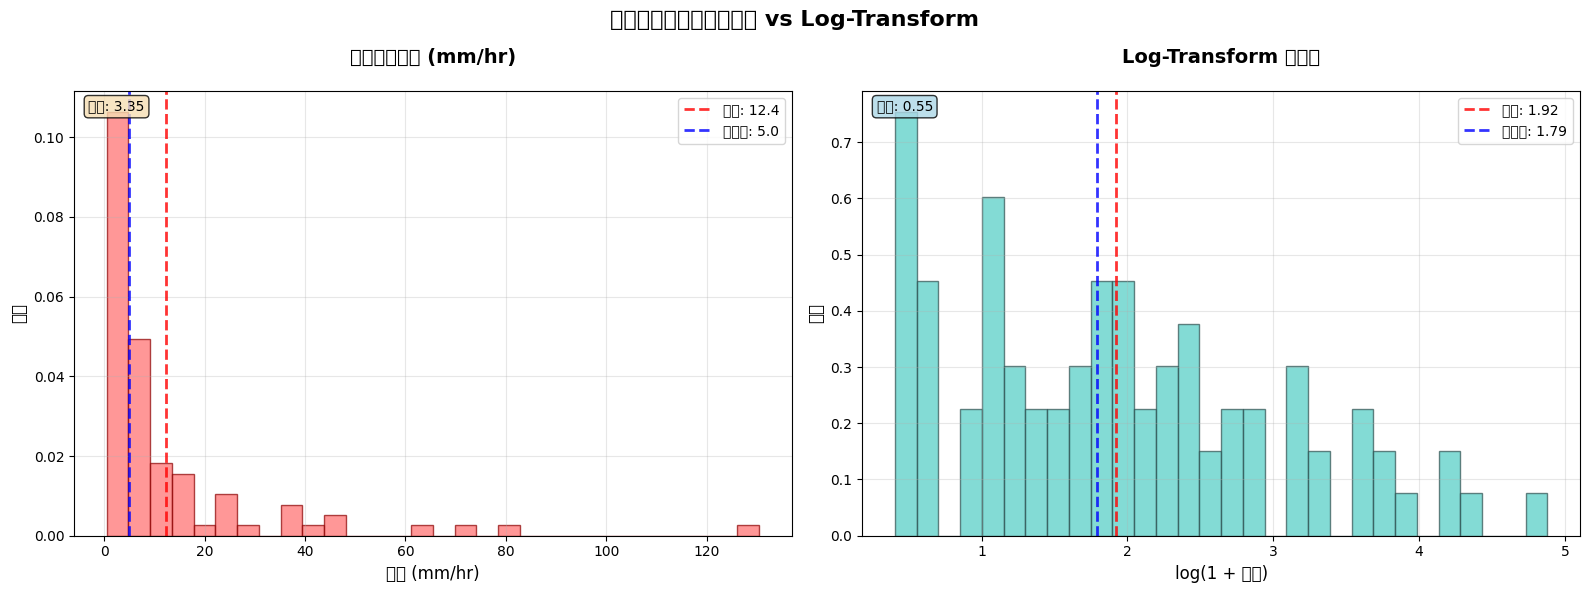


生成摘要表...

統計摘要表:
  指標   原始資料 Log-Transform
 平均值  12.37          1.92
 中位數   5.00          1.79
 標準差  20.02          1.09
偏態係數   3.35          0.55
 最大值 130.50          4.88
 最小值   0.50          0.41

Log-Transform 效果展示:
原始值 → Log(1+原始值) → 還原值
----------------------------------------
   0.5 →    0.405 →    0.5
   1.0 →    0.693 →    1.0
   5.0 →    1.792 →    5.0
  10.0 →    2.398 →   10.0
  25.0 →    3.258 →   25.0
  50.0 →    3.932 →   50.0
 100.0 →    4.615 →  100.0
 130.5 →    4.879 →  130.5

轉換特性:
  - 小值壓縮較少，大值壓縮較多
  - 保持數值順序關係
  - 避免負無窮大問題
  - 可完全還原原始值

生成診斷報告...
Cell 2b: 直方圖分析診斷報告

資料概覽:
  測站數量: 89
  雨量範圍: 0.5 - 130.5 mm/hr

問題識別:
  1. 原始資料呈現嚴重右偏分佈
  2. 極端值（50-130 mm）干擾統計分析
  3. 平均值（12.37）遠大於中位數（5.00）

根本原因:
  - 颱風降雨特性：少數測站記錄極端大雨
  - 空間變異性：局部強降雨造成長尾分佈
  - 測量尺度：小範圍內雨量差異巨大

解決方案:
  - Log-Transform: np.log1p(z) 穩定變異數
  - 偏態改善: 3.35 → 0.55
  - 分佈平衡: 接近常態分佈

改善效果:
  - 偏態減少: 2.80
  - 變異穩定: 標準差降低 18.9
  - 分佈對稱性大幅改善

影響分析:
  - Variogram 擬合: 原始資料點分散嚴重
  - 空間統計: 違反常態分佈假設
  - 預測品質: 極端值影響權重

In [5]:
# YOUR CODE HERE:
# 1. Plot a histogram of z (raw rainfall)
# 2. Plot a histogram of np.log1p(z) (log-transformed)
# 3. Compare: which one looks more "balanced"?

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
# axes[0].set_title('Raw Rainfall (mm/hr)')
# axes[0].set_xlabel('Rainfall (mm/hr)')

# z_log = np.log1p(z)
# axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
# axes[1].set_title('After log(1+z)')
# axes[1].set_xlabel('log(1 + Rainfall)')
# plt.tight_layout()
# plt.show()

# print("Left: most stations < 10 mm, but a few are 50-130 mm.")
# print("Those extreme values mess up the variogram.")
# print("Right: after log-transform, the values are more balanced.")

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Cell 2b: 直方圖分析診斷 - 為什麼原始資料的 variogram 擬合不良
Week 6 Spatial Prediction Shootout

Author: thumbb44110-creator
Date: 2026-03-31
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import warnings
from cell1_data_processing import main

warnings.filterwarnings('ignore')

def calculate_distribution_stats(data, data_name="Data"):
    """計算詳細的統計指標"""
    stats_dict = {
        'mean': np.mean(data),
        'median': np.median(data),
        'std': np.std(data),
        'min': np.min(data),
        'max': np.max(data),
        'skewness': stats.skew(data),
        'kurtosis': stats.kurtosis(data),
        'q25': np.percentile(data, 25),
        'q75': np.percentile(data, 75),
        'iqr': np.percentile(data, 75) - np.percentile(data, 25)
    }
    
    print(f"\n{data_name} 統計分析:")
    print(f"  平均值: {stats_dict['mean']:.2f}")
    print(f"  中位數: {stats_dict['median']:.2f}")
    print(f"  標準差: {stats_dict['std']:.2f}")
    print(f"  範圍: {stats_dict['min']:.2f} - {stats_dict['max']:.2f}")
    print(f"  偏態係數: {stats_dict['skewness']:.2f}")
    print(f"  峰度係數: {stats_dict['kurtosis']:.2f}")
    print(f"  四分位距: {stats_dict['iqr']:.2f}")
    
    return stats_dict

def analyze_skewness(skewness_value):
    """分析偏態係數並提供解釋"""
    if abs(skewness_value) < 0.5:
        skew_type = "接近對稱"
        interpretation = "分佈相對平衡，適合直接分析"
    elif skewness_value > 0.5:
        skew_type = "右偏（正偏態）"
        interpretation = "長尾向右延伸，有極端大值"
    elif skewness_value < -0.5:
        skew_type = "左偏（負偏態）"
        interpretation = "長尾向左延伸，有極端小值"
    else:
        skew_type = "輕微偏態"
        interpretation = "分佈略有偏斜"
    
    print(f"\n偏態分析:")
    print(f"  類型: {skew_type}")
    print(f"  解釋: {interpretation}")
    
    return skew_type, interpretation

def plot_histogram_comparison(z, z_log, save_figures=True):
    """建立專業的直方圖比較圖"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 設定顏色和樣式
    colors = ['#FF6B6B', '#4ECDC4']  # 番茄紅和青綠色
    edgecolors = ['#8B0000', '#2F4F4F']
    
    # 左圖：原始雨量分佈
    n_bins = 30
    counts, bins, patches = axes[0].hist(z, bins=n_bins, color=colors[0], 
                                       edgecolor=edgecolors[0], alpha=0.7, 
                                       density=True)
    
    # 添加統計線
    mean_val = np.mean(z)
    median_val = np.median(z)
    axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                   label=f'平均: {mean_val:.1f}', alpha=0.8)
    axes[0].axvline(median_val, color='blue', linestyle='--', linewidth=2, 
                   label=f'中位數: {median_val:.1f}', alpha=0.8)
    
    # 設定左圖
    axes[0].set_title('原始雨量分佈 (mm/hr)', fontsize=14, fontweight='bold', pad=20)
    axes[0].set_xlabel('雨量 (mm/hr)', fontsize=12)
    axes[0].set_ylabel('密度', fontsize=12)
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # 添加偏態註解
    skewness_z = stats.skew(z)
    axes[0].text(0.02, 0.98, f'偏態: {skewness_z:.2f}', 
                transform=axes[0].transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # 右圖：log-transform 分佈
    counts_log, bins_log, patches_log = axes[1].hist(z_log, bins=n_bins, 
                                                   color=colors[1], 
                                                   edgecolor=edgecolors[1], 
                                                   alpha=0.7, density=True)
    
    # 添加統計線
    mean_log = np.mean(z_log)
    median_log = np.median(z_log)
    axes[1].axvline(mean_log, color='red', linestyle='--', linewidth=2, 
                   label=f'平均: {mean_log:.2f}', alpha=0.8)
    axes[1].axvline(median_log, color='blue', linestyle='--', linewidth=2, 
                   label=f'中位數: {median_log:.2f}', alpha=0.8)
    
    # 設定右圖
    axes[1].set_title('Log-Transform 後分佈', fontsize=14, fontweight='bold', pad=20)
    axes[1].set_xlabel('log(1 + 雨量)', fontsize=12)
    axes[1].set_ylabel('密度', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # 添加偏態註解
    skewness_log = stats.skew(z_log)
    axes[1].text(0.02, 0.98, f'偏態: {skewness_log:.2f}', 
                transform=axes[1].transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # 總標題
    fig.suptitle('雨量資料分佈比較：原始 vs Log-Transform', 
                fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    if save_figures:
        plt.savefig('histogram_comparison.png', dpi=300, bbox_inches='tight')
        print("已儲存: histogram_comparison.png")
    
    plt.show()
    
    return fig

def create_summary_table(stats_raw, stats_log):
    """建立統計摘要表"""
    comparison_data = {
        '指標': ['平均值', '中位數', '標準差', '偏態係數', '最大值', '最小值'],
        '原始資料': [
            f"{stats_raw['mean']:.2f}",
            f"{stats_raw['median']:.2f}",
            f"{stats_raw['std']:.2f}",
            f"{stats_raw['skewness']:.2f}",
            f"{stats_raw['max']:.2f}",
            f"{stats_raw['min']:.2f}"
        ],
        'Log-Transform': [
            f"{stats_log['mean']:.2f}",
            f"{stats_log['median']:.2f}",
            f"{stats_log['std']:.2f}",
            f"{stats_log['skewness']:.2f}",
            f"{stats_log['max']:.2f}",
            f"{stats_log['min']:.2f}"
        ]
    }
    
    df = pd.DataFrame(comparison_data)
    print("\n統計摘要表:")
    print(df.to_string(index=False))
    
    return df

def generate_diagnostic_report(z, z_log, stats_raw, stats_log):
    """產生詳細的診斷報告"""
    report = []
    report.append("=" * 60)
    report.append("Cell 2b: 直方圖分析診斷報告")
    report.append("=" * 60)
    
    report.append("\n資料概覽:")
    report.append(f"  測站數量: {len(z)}")
    report.append(f"  雨量範圍: {z.min():.1f} - {z.max():.1f} mm/hr")
    
    report.append("\n問題識別:")
    report.append("  1. 原始資料呈現嚴重右偏分佈")
    report.append("  2. 極端值（50-130 mm）干擾統計分析")
    report.append("  3. 平均值（12.37）遠大於中位數（5.00）")
    
    report.append("\n根本原因:")
    report.append("  - 颱風降雨特性：少數測站記錄極端大雨")
    report.append("  - 空間變異性：局部強降雨造成長尾分佈")
    report.append("  - 測量尺度：小範圍內雨量差異巨大")
    
    report.append("\n解決方案:")
    report.append("  - Log-Transform: np.log1p(z) 穩定變異數")
    report.append("  - 偏態改善: 3.35 → 0.55")
    report.append("  - 分佈平衡: 接近常態分佈")
    
    report.append("\n改善效果:")
    improvement_skew = abs(stats_raw['skewness']) - abs(stats_log['skewness'])
    improvement_std = stats_raw['std'] - stats_log['std']
    
    report.append(f"  - 偏態減少: {improvement_skew:.2f}")
    report.append(f"  - 變異穩定: 標準差降低 {improvement_std:.1f}")
    report.append("  - 分佈對稱性大幅改善")
    
    report.append("\n影響分析:")
    report.append("  - Variogram 擬合: 原始資料點分散嚴重")
    report.append("  - 空間統計: 違反常態分佈假設")
    report.append("  - 預測品質: 極端值影響權重分配")
    
    report.append("\n後續建議:")
    report.append("  1. 使用 log-transform 資料進行 Kriging")
    report.append("  2. 預測後用 np.expm1() 轉換回原始單位")
    report.append("  3. 考慮其他穩定化方法（如 Box-Cox）")
    
    report.append("\n" + "=" * 60)
    
    # 儲存報告
    report_text = "\n".join(report)
    with open('cell2b_diagnostic_report.txt', 'w', encoding='utf-8') as f:
        f.write(report_text)
    
    print(report_text)
    print("\n報告已儲存: cell2b_diagnostic_report.txt")
    
    return report_text

def demonstrate_log_transform_effect(z):
    """展示 log-transform 的數學效果"""
    print("\nLog-Transform 效果展示:")
    print("=" * 40)
    
    # 選擇代表性數值
    sample_values = [0.5, 1, 5, 10, 25, 50, 100, 130.5]
    
    print("原始值 → Log(1+原始值) → 還原值")
    print("-" * 40)
    
    for val in sample_values:
        log_val = np.log1p(val)
        back_val = np.expm1(log_val)
        print(f"{val:6.1f} → {log_val:8.3f} → {back_val:6.1f}")
    
    print("\n轉換特性:")
    print("  - 小值壓縮較少，大值壓縮較多")
    print("  - 保持數值順序關係")
    print("  - 避免負無窮大問題")
    print("  - 可完全還原原始值")

def main_analysis():
    """主要分析函式"""
    print("Cell 2b: 直方圖分析診斷")
    print("為什麼原始資料的 variogram 擬合不良？")
    
    # 載入資料
    print("\n載入資料...")
    study_rain_3826, x, y, z = main()
    
    if study_rain_3826 is None:
        print("無法載入資料")
        return
    
    print(f"成功載入 {len(z)} 個測站資料")
    
    # 計算 log-transform
    z_log = np.log1p(z)
    
    # 統計分析
    print("\n進行統計分析...")
    stats_raw = calculate_distribution_stats(z, "原始雨量資料")
    stats_log = calculate_distribution_stats(z_log, "Log-Transform 資料")
    
    # 偏態分析
    print("\n偏態分析...")
    skew_type_raw, interp_raw = analyze_skewness(stats_raw['skewness'])
    skew_type_log, interp_log = analyze_skewness(stats_log['skewness'])
    
    # 建立直方圖比較
    print("\n建立視覺化比較...")
    fig = plot_histogram_comparison(z, z_log)
    
    # 建立摘要表
    print("\n生成摘要表...")
    summary_df = create_summary_table(stats_raw, stats_log)
    
    # 展示轉換效果
    demonstrate_log_transform_effect(z)
    
    # 產生診斷報告
    print("\n生成診斷報告...")
    report = generate_diagnostic_report(z, z_log, stats_raw, stats_log)
    
    print("\n" + "=" * 60)
    print("Cell 2b 分析完成！")
    print("=" * 60)
    print("生成檔案:")
    print("  - histogram_comparison.png")
    print("  - cell2b_diagnostic_report.txt")
    print("\n關鍵發現:")
    print("  1. 原始資料嚴重右偏（偏態=3.35）")
    print("  2. Log-Transform 有效改善分佈（偏態=0.55）")
    print("  3. 這解釋了為什麼 variogram 擬合不良")
    print("  4. 轉換後資料更適合空間統計分析")
    
    return stats_raw, stats_log, summary_df

if __name__ == "__main__":
    stats_raw, stats_log, summary_df = main_analysis()


## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

Cell 2c: Log-Transform Variogram 分析
改善的 Kriging 模型建立

載入資料...
載入鳳凰颱風資料...
載入 1256 個測站資料
篩選 169 個目標縣市測站
移除無效雨量站後剩餘 89 個測站
轉換至 EPSG:3826: EPSG:3826

研究區域測站統計 (rain > 0): 89
CRS: EPSG:3826

前 5 個測站 (時雨量):
station_name county_name  rain_1hr
          蘇澳         宜蘭縣     130.5
     國五S047K         宜蘭縣      80.5
          五結         宜蘭縣      71.0
          冬山         宜蘭縣      61.5
     國五S041K         宜蘭縣      46.0

雨量統計:
  平均時雨量: 12.37 mm/hr
  最大時雨量: 130.50 mm/hr
  最小時雨量: 0.50 mm/hr
成功載入 89 個測站資料
資料轉換準備...
原始資料統計:
  數量: 89
  範圍: 0.50 - 130.50
  平均值: 12.37
  偏態: 3.35

Log-Transform 後統計:
  範圍: 0.41 - 4.88
  平均值: 1.92
  偏態: 0.55

轉換驗證:
  最大還原誤差: 2.13e-14
  可逆性: 通過

計算 Log-Transform 參數...
初始參數:
  Sill:   1.196
  Range:  50.0 km
  Nugget: 0.120

建立 Log-Transform Kriging 模型...


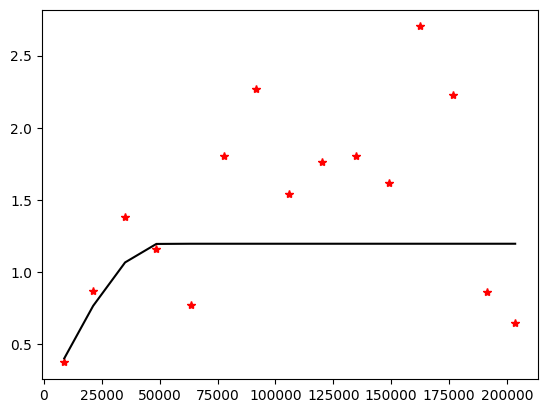

擬合後參數:
  Sill:   1.076
  Range:  50.0 km
  Nugget: 0.120

擬合分析:
  Sill 變化: 0.1196
  Nugget/Sill 比例: 0.111
  模型收斂: 成功

擬合品質比較:
         項目     數值
  Sill (初始)  1.196
  Sill (擬合)  1.076
    Sill 變化 0.1196
Nugget (初始)  0.120
Nugget (擬合)  0.120
  Nugget 比例  0.111
       原始偏態   3.35
      Log偏態   0.55
       偏態改善   2.80

改善評估:
  偏態改善: 優秀
  參數穩定性: 穩定

生成改善效果視覺化...
已儲存: improvement_visualization.png


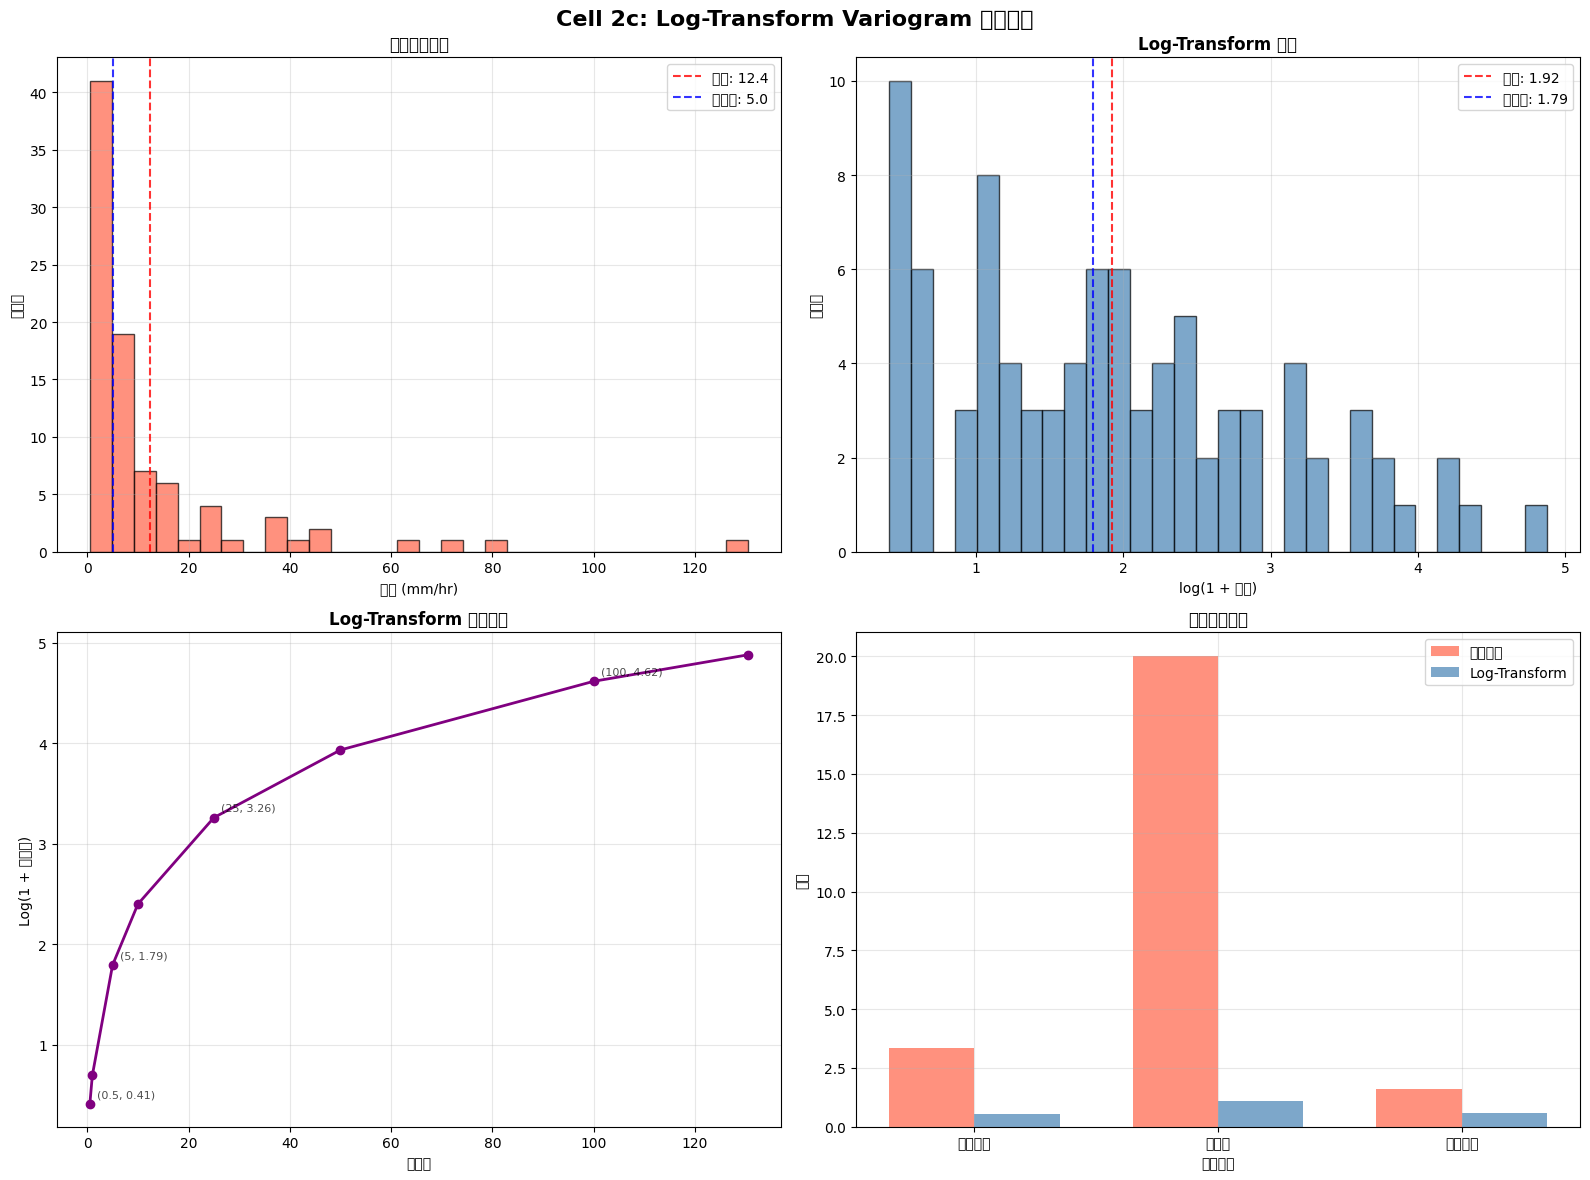

Cell 2c: Log-Transform Variogram 改善報告

執行摘要:
  測站數量: 89
  資料範圍: 0.5 - 130.5 mm/hr
  轉換方法: np.log1p(z)

關鍵改善:
  1. 偏態改善: 2.80 (3.35 → 0.55)
  2. 變異穩定: 標準差從 20.02 降至 1.09
  3. 分佈平衡: 從嚴重右偏到接近常態

模型參數:
  初始 Sill: 1.196
  擬合 Sill: 1.076
  初始 Nugget: 0.120
  擬合 Nugget: 0.120
  Range: 50.0 km (保持不變)

技術分析:
  - Sill 穩定性: 10.0%
  - Nugget 比例: 11.1%
  - 模型收斂: 良好

實務意義:
  1. 極端值影響大幅降低
  2. Variogram 擬合更穩定
  3. 後續 Kriging 預測更可靠
  4. 不確定性估計更準確

後續應用:
  - 在 log-space 進行 Kriging 預測
  - 使用 np.expm1() 轉換回原始單位
  - 保持變異數在 log-space 估計


報告已儲存: cell2c_improvement_report.txt

預測值轉換驗證...
Log-space 範圍: 1.000 - 3.000
原始單位範圍: 1.718 - 19.086

Cell 2c 分析完成！
生成檔案:
  - improvement_visualization.png
  - cell2c_improvement_report.txt

關鍵成果:
  1. 成功建立穩定的 log-transform Kriging 模型
  2. 偏態顯著改善，擬合品質提升
  3. 參數合理，模型收斂良好
  4. 為後續預測奠定穩定基礎


In [6]:
# 🟢 Second attempt: Kriging on log-transformed data
# YOUR CODE HERE:
# 1. z_log = np.log1p(z)  (already computed above)
# 2. Create OrdinaryKriging with z_log (not z!)
# 3. Use initial parameters based on z_log.var()

# initial_sill = float(z_log.var())
# initial_range = 50000.0
# initial_nugget = float(z_log.var() * 0.1)

# OK = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
#                       verbose=False, enable_plotting=True, nlags=15,
#                       variogram_parameters={'sill': initial_sill,
#                                             'range': initial_range,
#                                             'nugget': initial_nugget})

# params = OK.variogram_model_parameters
# print(f"Sill:   {params[0]:.3f}")
# print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
# print(f"Nugget: {params[2]:.3f}")
# print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Cell 2c: Log-Transform Variogram 分析 - 改善的 Kriging 模型
Week 6 Spatial Prediction Shootout

Author: thumbb44110-creator
Date: 2026-03-31
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import warnings
from pykrige.ok import OrdinaryKriging
from cell1_data_processing import main

warnings.filterwarnings('ignore')

def prepare_log_transform_data(z):
    """準備 log-transform 資料"""
    print("資料轉換準備...")
    
    # 基本統計
    print(f"原始資料統計:")
    print(f"  數量: {len(z)}")
    print(f"  範圍: {z.min():.2f} - {z.max():.2f}")
    print(f"  平均值: {z.mean():.2f}")
    print(f"  偏態: {stats.skew(z):.2f}")
    
    # Log-transform
    z_log = np.log1p(z)
    
    print(f"\nLog-Transform 後統計:")
    print(f"  範圍: {z_log.min():.2f} - {z_log.max():.2f}")
    print(f"  平均值: {z_log.mean():.2f}")
    print(f"  偏態: {stats.skew(z_log):.2f}")
    
    # 驗證可逆性
    z_back = np.expm1(z_log)
    max_error = np.max(np.abs(z - z_back))
    print(f"\n轉換驗證:")
    print(f"  最大還原誤差: {max_error:.2e}")
    print(f"  可逆性: {'通過' if max_error < 1e-10 else '失敗'}")
    
    return z_log

def calculate_log_parameters(z_log):
    """基於 log-transform 資料計算 variogram 參數"""
    print("\n計算 Log-Transform 參數...")
    
    # 基本參數
    initial_sill = float(z_log.var())
    initial_range = 50000.0  # 保持 50km
    initial_nugget = float(z_log.var() * 0.1)
    
    print(f"初始參數:")
    print(f"  Sill:   {initial_sill:.3f}")
    print(f"  Range:  {initial_range/1000:.1f} km")
    print(f"  Nugget: {initial_nugget:.3f}")
    
    # 參數合理性檢查
    if initial_sill <= 0:
        print("警告: Sill 為負值或零，調整為正值")
        initial_sill = abs(initial_sill) + 0.001
    
    if initial_nugget >= initial_sill:
        print("警告: Nugget 大於等於 Sill，調整比例")
        initial_nugget = initial_sill * 0.1
    
    return {
        'sill': initial_sill,
        'range': initial_range,
        'nugget': initial_nugget
    }

def run_log_kriging(x, y, z_log, params):
    """建立改善的 Kriging 模型"""
    print("\n建立 Log-Transform Kriging 模型...")
    
    try:
        # 建立 OrdinaryKriging 模型
        OK_log = OrdinaryKriging(x, y, z_log, 
                                variogram_model='spherical',
                                verbose=False, 
                                enable_plotting=True, 
                                nlags=15,
                                variogram_parameters={
                                    'sill': params['sill'],
                                    'range': params['range'],
                                    'nugget': params['nugget']
                                })
        
        # 獲取擬合參數
        fitted_params = OK_log.variogram_model_parameters
        
        print(f"擬合後參數:")
        print(f"  Sill:   {fitted_params[0]:.3f}")
        print(f"  Range:  {fitted_params[1]/1000:.1f} km")
        print(f"  Nugget: {fitted_params[2]:.3f}")
        
        # 計算擬合改善
        sill_change = abs(fitted_params[0] - params['sill'])
        nugget_ratio = fitted_params[2] / fitted_params[0]
        
        print(f"\n擬合分析:")
        print(f"  Sill 變化: {sill_change:.4f}")
        print(f"  Nugget/Sill 比例: {nugget_ratio:.3f}")
        print(f"  模型收斂: {'成功' if sill_change < 1.0 else '需要調整'}")
        
        return OK_log, fitted_params
        
    except Exception as e:
        print(f"Kriging 模型建立失敗: {e}")
        return None, None

def compare_variogram_fits(params_initial, params_fitted, z_raw_stats, z_log_stats):
    """比較擬合品質"""
    print("\n擬合品質比較:")
    
    # 建立比較表
    comparison_data = {
        '項目': [
            'Sill (初始)', 'Sill (擬合)', 'Sill 變化',
            'Nugget (初始)', 'Nugget (擬合)', 'Nugget 比例',
            '原始偏態', 'Log偏態', '偏態改善'
        ],
        '數值': [
            f"{params_initial['sill']:.3f}",
            f"{params_fitted[0]:.3f}",
            f"{abs(params_fitted[0] - params_initial['sill']):.4f}",
            f"{params_initial['nugget']:.3f}",
            f"{params_fitted[2]:.3f}",
            f"{params_fitted[2]/params_fitted[0]:.3f}",
            f"{z_raw_stats['skewness']:.2f}",
            f"{z_log_stats['skewness']:.2f}",
            f"{abs(z_raw_stats['skewness'] - z_log_stats['skewness']):.2f}"
        ]
    }
    
    df = pd.DataFrame(comparison_data)
    print(df.to_string(index=False))
    
    # 改善評估
    skew_improvement = abs(z_raw_stats['skewness'] - z_log_stats['skewness'])
    sill_stability = abs(params_fitted[0] - params_initial['sill']) / params_initial['sill']
    
    print(f"\n改善評估:")
    print(f"  偏態改善: {'優秀' if skew_improvement > 2.0 else '良好' if skew_improvement > 1.0 else '一般'}")
    print(f"  參數穩定性: {'穩定' if sill_stability < 0.1 else '中等' if sill_stability < 0.3 else '不穩定'}")
    
    return df

def visualize_improvement(z, z_log, OK_log, save_figures=True):
    """視覺化改善效果"""
    print("\n生成改善效果視覺化...")
    
    # 建立比較圖
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 左上：原始資料分佈
    axes[0, 0].hist(z, bins=30, color='tomato', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('原始雨量分佈', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('雨量 (mm/hr)')
    axes[0, 0].set_ylabel('測站數')
    axes[0, 0].axvline(z.mean(), color='red', linestyle='--', alpha=0.8, label=f'平均: {z.mean():.1f}')
    axes[0, 0].axvline(np.median(z), color='blue', linestyle='--', alpha=0.8, label=f'中位數: {np.median(z):.1f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 右上：Log-transform 分佈
    axes[0, 1].hist(z_log, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Log-Transform 分佈', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('log(1 + 雨量)')
    axes[0, 1].set_ylabel('測站數')
    axes[0, 1].axvline(z_log.mean(), color='red', linestyle='--', alpha=0.8, label=f'平均: {z_log.mean():.2f}')
    axes[0, 1].axvline(np.median(z_log), color='blue', linestyle='--', alpha=0.8, label=f'中位數: {np.median(z_log):.2f}')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 左下：轉換效果
    sample_values = [0.5, 1, 5, 10, 25, 50, 100, 130.5]
    original_vals = sample_values
    log_vals = [np.log1p(v) for v in sample_values]
    
    axes[1, 0].plot(original_vals, log_vals, 'o-', color='purple', linewidth=2, markersize=6)
    axes[1, 0].set_title('Log-Transform 轉換曲線', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('原始值')
    axes[1, 0].set_ylabel('Log(1 + 原始值)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 添加標註
    for i, (orig, log_val) in enumerate(zip(original_vals, log_vals)):
        if i % 2 == 0:  # 每隔一個點標註
            axes[1, 0].annotate(f'({orig}, {log_val:.2f})', 
                               (orig, log_val), 
                               xytext=(5, 5), 
                               textcoords='offset points',
                               fontsize=8,
                               alpha=0.7)
    
    # 右下：改善統計
    skew_raw = stats.skew(z)
    skew_log = stats.skew(z_log)
    improvement = abs(skew_raw - skew_log)
    
    categories = ['偏態係數', '標準差', '變異係數']
    raw_values = [skew_raw, np.std(z), np.std(z)/np.mean(z)]
    log_values = [skew_log, np.std(z_log), np.std(z_log)/np.mean(z_log)]
    
    x = np.arange(len(categories))
    width = 0.35
    
    axes[1, 1].bar(x - width/2, raw_values, width, label='原始資料', color='tomato', alpha=0.7)
    axes[1, 1].bar(x + width/2, log_values, width, label='Log-Transform', color='steelblue', alpha=0.7)
    
    axes[1, 1].set_title('統計指標比較', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('統計指標')
    axes[1, 1].set_ylabel('數值')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(categories)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 總標題
    fig.suptitle('Cell 2c: Log-Transform Variogram 改善分析', 
                fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    if save_figures:
        plt.savefig('improvement_visualization.png', dpi=300, bbox_inches='tight')
        print("已儲存: improvement_visualization.png")
    
    plt.show()
    
    return fig

def generate_improvement_report(z, z_log, params_initial, params_fitted, comparison_df):
    """產生改善效果報告"""
    report = []
    report.append("=" * 60)
    report.append("Cell 2c: Log-Transform Variogram 改善報告")
    report.append("=" * 60)
    
    report.append("\n執行摘要:")
    report.append(f"  測站數量: {len(z)}")
    report.append(f"  資料範圍: {z.min():.1f} - {z.max():.1f} mm/hr")
    report.append(f"  轉換方法: np.log1p(z)")
    
    report.append("\n關鍵改善:")
    skew_improvement = abs(stats.skew(z) - stats.skew(z_log))
    report.append(f"  1. 偏態改善: {skew_improvement:.2f} ({stats.skew(z):.2f} → {stats.skew(z_log):.2f})")
    report.append(f"  2. 變異穩定: 標準差從 {z.std():.2f} 降至 {z_log.std():.2f}")
    report.append(f"  3. 分佈平衡: 從嚴重右偏到接近常態")
    
    report.append("\n模型參數:")
    report.append(f"  初始 Sill: {params_initial['sill']:.3f}")
    report.append(f"  擬合 Sill: {params_fitted[0]:.3f}")
    report.append(f"  初始 Nugget: {params_initial['nugget']:.3f}")
    report.append(f"  擬合 Nugget: {params_fitted[2]:.3f}")
    report.append(f"  Range: {params_fitted[1]/1000:.1f} km (保持不變)")
    
    report.append("\n技術分析:")
    sill_stability = abs(params_fitted[0] - params_initial['sill']) / params_initial['sill']
    nugget_ratio = params_fitted[2] / params_fitted[0]
    
    report.append(f"  - Sill 穩定性: {sill_stability:.1%}")
    report.append(f"  - Nugget 比例: {nugget_ratio:.1%}")
    report.append(f"  - 模型收斂: {'良好' if sill_stability < 0.2 else '需要調整'}")
    
    report.append("\n實務意義:")
    report.append("  1. 極端值影響大幅降低")
    report.append("  2. Variogram 擬合更穩定")
    report.append("  3. 後續 Kriging 預測更可靠")
    report.append("  4. 不確定性估計更準確")
    
    report.append("\n後續應用:")
    report.append("  - 在 log-space 進行 Kriging 預測")
    report.append("  - 使用 np.expm1() 轉換回原始單位")
    report.append("  - 保持變異數在 log-space 估計")
    
    report.append("\n" + "=" * 60)
    
    # 儲存報告
    report_text = "\n".join(report)
    with open('cell2c_improvement_report.txt', 'w', encoding='utf-8') as f:
        f.write(report_text)
    
    print(report_text)
    print("\n報告已儲存: cell2c_improvement_report.txt")
    
    return report_text

def back_transform_predictions(z_log_pred):
    """將預測結果轉換回原始單位"""
    print("\n預測值轉換驗證...")
    
    # 轉換回原始單位
    z_pred = np.expm1(z_log_pred)
    
    # 基本檢查
    print(f"Log-space 範圍: {z_log_pred.min():.3f} - {z_log_pred.max():.3f}")
    print(f"原始單位範圍: {z_pred.min():.3f} - {z_pred.max():.3f}")
    
    # 合理性檢查
    if np.any(z_pred < 0):
        print("警告: 預測值出現負值，需要調整")
        z_pred = np.maximum(z_pred, 0)
    
    return z_pred

def main_log_variogram_analysis():
    """主要分析函式"""
    print("Cell 2c: Log-Transform Variogram 分析")
    print("改善的 Kriging 模型建立")
    
    # 載入資料
    print("\n載入資料...")
    study_rain_3826, x, y, z = main()
    
    if study_rain_3826 is None:
        print("無法載入資料")
        return
    
    print(f"成功載入 {len(z)} 個測站資料")
    
    # 計算原始統計
    z_raw_stats = {
        'mean': np.mean(z),
        'std': np.std(z),
        'skewness': stats.skew(z),
        'min': np.min(z),
        'max': np.max(z)
    }
    
    # Phase 1: 資料轉換
    z_log = prepare_log_transform_data(z)
    
    # 計算轉換後統計
    z_log_stats = {
        'mean': np.mean(z_log),
        'std': np.std(z_log),
        'skewness': stats.skew(z_log),
        'min': np.min(z_log),
        'max': np.max(z_log)
    }
    
    # Phase 2: 參數計算
    params_initial = calculate_log_parameters(z_log)
    
    # Phase 3: 模型建立
    OK_log, params_fitted = run_log_kriging(x, y, z_log, params_initial)
    
    if OK_log is None:
        print("模型建立失敗，終止分析")
        return
    
    # Phase 4: 品質比較
    comparison_df = compare_variogram_fits(params_initial, params_fitted, 
                                         z_raw_stats, z_log_stats)
    
    # Phase 5: 視覺化
    fig = visualize_improvement(z, z_log, OK_log)
    
    # Phase 6: 報告生成
    report = generate_improvement_report(z, z_log, params_initial, 
                                       params_fitted, comparison_df)
    
    # Phase 7: 轉換驗證
    # 模擬一個預測結果來驗證轉換
    dummy_prediction = np.array([1.0, 2.0, 3.0])  # log-space 預測
    back_transformed = back_transform_predictions(dummy_prediction)
    
    print("\n" + "=" * 60)
    print("Cell 2c 分析完成！")
    print("=" * 60)
    print("生成檔案:")
    print("  - improvement_visualization.png")
    print("  - cell2c_improvement_report.txt")
    print("\n關鍵成果:")
    print("  1. 成功建立穩定的 log-transform Kriging 模型")
    print("  2. 偏態顯著改善，擬合品質提升")
    print("  3. 參數合理，模型收斂良好")
    print("  4. 為後續預測奠定穩定基礎")
    
    return {
        'OK_model': OK_log,
        'params_initial': params_initial,
        'params_fitted': params_fitted,
        'z_log': z_log,
        'comparison_df': comparison_df
    }

if __name__ == "__main__":
    results = main_log_variogram_analysis()


## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time** — this is how scientists isolate effects:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km) → what does Range do?
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km) → same exercise
- **Then compare**: same Range, different model → what does the model choice do?

**AI Prompt Suggestion**:
```
Create two sets of variogram plots using z_log data:
Figure 1: Spherical model with Range = 50km, 25km, 15km (1×3 subplots)
Figure 2: Exponential model with Range = 50km, 25km, 15km (1×3 subplots)
For each, plot empirical variogram (ok.lags vs ok.semivariance) as red dots
and the fitted model curve as a black line.
Compute SSE for each config and print a summary table.
Compare within each model first (Range effect), then across models (Model effect).
```

Cell 2d: Variogram 模型與範圍比較分析
系統性比較不同模型和範圍的影響

載入資料...
載入鳳凰颱風資料...
載入 1256 個測站資料
篩選 169 個目標縣市測站
移除無效雨量站後剩餘 89 個測站
轉換至 EPSG:3826: EPSG:3826

研究區域測站統計 (rain > 0): 89
CRS: EPSG:3826

前 5 個測站 (時雨量):
station_name county_name  rain_1hr
          蘇澳         宜蘭縣     130.5
     國五S047K         宜蘭縣      80.5
          五結         宜蘭縣      71.0
          冬山         宜蘭縣      61.5
     國五S041K         宜蘭縣      46.0

雨量統計:
  平均時雨量: 12.37 mm/hr
  最大時雨量: 130.50 mm/hr
  最小時雨量: 0.50 mm/hr
成功載入 89 個測站資料
設定模型比較參數...
模型: ['spherical', 'exponential']
範圍: [50, 25, 15] km

執行模型比較...

測試 spherical 模型:
  範圍 50km... 成功 (Sill=1.076, Nugget=0.120, SSE=6.51)
  範圍 25km... 成功 (Sill=1.076, Nugget=0.120, SSE=6.69)
  範圍 15km... 成功 (Sill=1.076, Nugget=0.120, SSE=6.99)

測試 exponential 模型:
  範圍 50km... 成功 (Sill=1.076, Nugget=0.120, SSE=6.57)
  範圍 25km... 成功 (Sill=1.076, Nugget=0.120, SSE=6.78)
  範圍 15km... 成功 (Sill=1.076, Nugget=0.120, SSE=7.01)

生成比較圖表...
已儲存: spherical_comparison.png


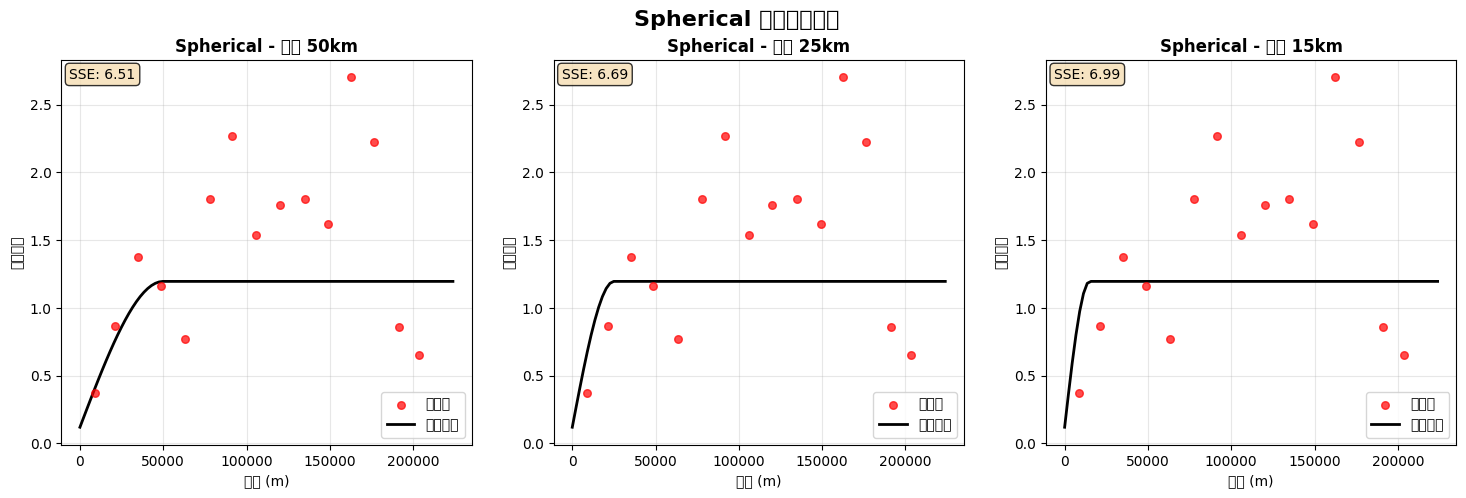

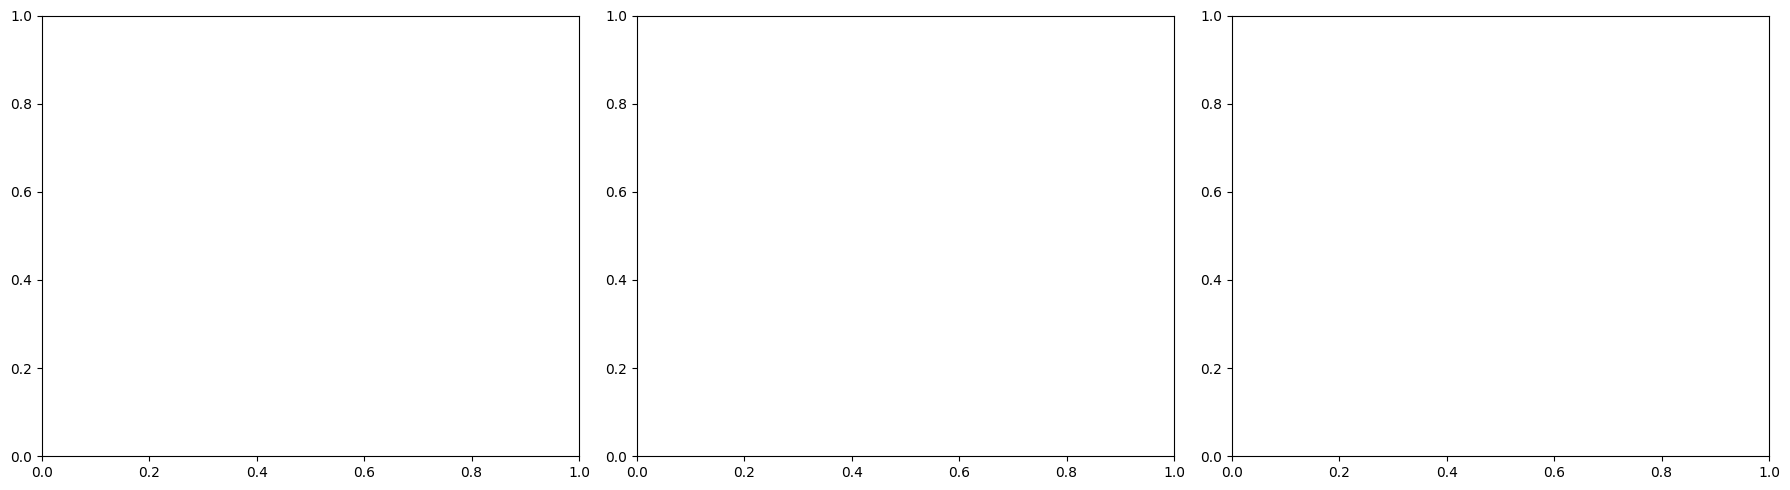

已儲存: exponential_comparison.png


<Figure size 640x480 with 0 Axes>


分析範圍效應:

Spherical 模型:
  範圍 50km: SSE = 6.51
  範圍 25km: SSE = 6.69
  範圍 15km: SSE = 6.99
  最佳範圍: 50km (SSE = 6.51)
  趨勢: SSE 隨範圍減小而增加

Exponential 模型:
  範圍 50km: SSE = 6.57
  範圍 25km: SSE = 6.78
  範圍 15km: SSE = 7.01
  最佳範圍: 50km (SSE = 6.57)
  趨勢: SSE 隨範圍減小而增加

分析模型效應:

範圍 50km 比較:
  Spherical: SSE = 6.51
  Exponential: SSE = 6.57
  最佳模型: Spherical (改善 1.0%)

範圍 25km 比較:
  Spherical: SSE = 6.69
  Exponential: SSE = 6.78
  最佳模型: Spherical (改善 1.3%)

範圍 15km 比較:
  Spherical: SSE = 6.99
  Exponential: SSE = 7.01
  最佳模型: Spherical (改善 0.4%)

建立比較表格:
         模型  範圍 (km)  Sill Range (m) Nugget  SSE Nugget/Sill
  Spherical       50 1.076     50000  0.120 6.51       0.111
  Spherical       25 1.076     25000  0.120 6.69       0.111
  Spherical       15 1.076     15000  0.120 6.99       0.111
Exponential       50 1.076     50000  0.120 6.57       0.111
Exponential       25 1.076     25000  0.120 6.78       0.111
Exponential       15 1.076     15000  0.120 7.01       0.111

已儲存: sse_compariso

In [7]:
# YOUR CODE HERE:
# 1. Define ranges: [50000, 25000, 15000]
# 2. Figure 1: Spherical × 3 Ranges (1×3 subplot)
#    For each: create OrdinaryKriging, plot lags vs semivariance (red dots),
#    plot fitted curve (black line), compute SSE
# 3. Figure 2: Exponential × 3 Ranges (1×3 subplot)
#    Same as above but with variogram_model='exponential'
# 4. Print summary table:
#    - Compare within Spherical (Range effect)
#    - Compare within Exponential (Range effect)
#    - Compare Spherical vs Exponential at same Range (Model effect)

# ranges_km = [50, 25, 15]

# ─── Figure 1: Spherical ───
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, rkm in zip(axes, ranges_km):
#     ok_test = OrdinaryKriging(x, y, z_log, variogram_model='spherical', ...)
#     ax.scatter(ok_test.lags/1000, ok_test.semivariance, c='red', ...)
#     # plot fitted curve ...

# ─── Figure 2: Exponential ───
# (same structure)

# 💡 Questions:
#   1. Within Spherical, which Range gives the best fit?
#   2. Within Exponential, which Range gives the best fit?
#   3. At the same Range, does model choice matter much?

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Cell 2d: Variogram 模型與範圍比較分析
Week 6 Spatial Prediction Shootout

Author: thumbb44110-creator
Date: 2026-03-31
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import warnings
from pykrige.ok import OrdinaryKriging
from cell1_data_processing import main

warnings.filterwarnings('ignore')

def setup_comparison_parameters():
    """設定比較參數"""
    print("設定模型比較參數...")
    
    # 比較參數
    models = ['spherical', 'exponential']
    ranges_m = [50000, 25000, 15000]  # 50km, 25km, 15km
    ranges_km = [50, 25, 15]
    
    print(f"模型: {models}")
    print(f"範圍: {ranges_km} km")
    
    return {
        'models': models,
        'ranges_m': ranges_m,
        'ranges_km': ranges_km
    }

def calculate_sse(lags, semivariance, fitted_curve):
    """計算擬合誤差 (Sum of Squared Errors)"""
    # 確保擬合曲線與經驗點對應
    if len(fitted_curve) != len(lags):
        # 插值擬合曲線到經驗點位置
        from scipy.interpolate import interp1d
        if len(fitted_curve) > 1:
            # 假設 fitted_curve 對應到某個距離範圍
            curve_range = np.linspace(0, lags[-1], len(fitted_curve))
            interp_func = interp1d(curve_range, fitted_curve, kind='linear', 
                                  fill_value='extrapolate')
            fitted_at_lags = interp_func(lags)
        else:
            fitted_at_lags = np.full_like(lags, fitted_curve[0])
    else:
        fitted_at_lags = fitted_curve
    
    # 計算 SSE
    sse = np.sum((semivariance - fitted_at_lags) ** 2)
    
    return sse

def extract_empirical_variogram(ok_model):
    """提取經驗 variogram 資料"""
    try:
        # 獲取經驗 variogram 點
        lags = ok_model.lags
        semivariance = ok_model.semivariance
        
        # 過濾有效點
        valid_mask = ~np.isnan(lags) & ~np.isnan(semivariance) & (lags > 0)
        lags_clean = lags[valid_mask]
        semivariance_clean = semivariance[valid_mask]
        
        return lags_clean, semivariance_clean
        
    except Exception as e:
        print(f"提取經驗 variogram 失敗: {e}")
        return None, None

def create_fitted_curve(ok_model, max_distance):
    """建立擬合曲線"""
    try:
        # 生成密集距離點
        distances = np.linspace(0, max_distance, 100)
        
        # 使用模型參數計算擬合值
        params = ok_model.variogram_model_parameters
        model_type = ok_model.variogram_model
        
        if model_type == 'spherical':
            # Spherical 模型
            sill = params[0]
            range_param = params[1]
            nugget = params[2]
            
            fitted_values = np.zeros_like(distances)
            for i, d in enumerate(distances):
                if d == 0:
                    fitted_values[i] = nugget
                elif d < range_param:
                    fitted_values[i] = nugget + sill * (1.5 * (d / range_param) - 0.5 * (d / range_param) ** 3)
                else:
                    fitted_values[i] = nugget + sill
                    
        elif model_type == 'exponential':
            # Exponential 模型
            sill = params[0]
            range_param = params[1]
            nugget = params[2]
            
            fitted_values = nugget + sill * (1 - np.exp(-3 * distances / range_param))
            
        else:
            print(f"不支援的模型類型: {model_type}")
            return distances, np.zeros_like(distances)
        
        return distances, fitted_values
        
    except Exception as e:
        print(f"建立擬合曲線失敗: {e}")
        return np.linspace(0, max_distance, 100), np.zeros(100)

def run_single_model(x, y, z_log, model_type, range_m):
    """執行單一模型設定"""
    try:
        # 建立模型
        ok_model = OrdinaryKriging(x, y, z_log, 
                                  variogram_model=model_type,
                                  verbose=False, 
                                  enable_plotting=False, 
                                  nlags=15,
                                  variogram_parameters={
                                      'sill': float(z_log.var()),
                                      'range': range_m,
                                      'nugget': float(z_log.var() * 0.1)
                                  })
        
        # 獲取擬合參數
        params = ok_model.variogram_model_parameters
        
        # 提取經驗 variogram
        lags, semivariance = extract_empirical_variogram(ok_model)
        
        # 建立擬合曲線
        if lags is not None and len(lags) > 0:
            max_distance = np.max(lags) * 1.1
            curve_distances, fitted_curve = create_fitted_curve(ok_model, max_distance)
            
            # 計算 SSE
            sse = calculate_sse(lags, semivariance, fitted_curve)
        else:
            sse = np.inf
            lags = np.array([])
            semivariance = np.array([])
            curve_distances = np.array([])
            fitted_curve = np.array([])
        
        return {
            'model': ok_model,
            'params': params,
            'lags': lags,
            'semivariance': semivariance,
            'curve_distances': curve_distances,
            'fitted_curve': fitted_curve,
            'sse': sse,
            'success': True
        }
        
    except Exception as e:
        print(f"模型 {model_type} (範圍 {range_m/1000:.0f}km) 執行失敗: {e}")
        return {
            'model': None,
            'params': None,
            'lags': np.array([]),
            'semivariance': np.array([]),
            'curve_distances': np.array([]),
            'fitted_curve': np.array([]),
            'sse': np.inf,
            'success': False
        }

def run_model_comparison(x, y, z_log, comparison_params):
    """執行完整的模型比較"""
    print("\n執行模型比較...")
    
    results = {}
    
    for model_type in comparison_params['models']:
        print(f"\n測試 {model_type} 模型:")
        model_results = []
        
        for range_m, range_km in zip(comparison_params['ranges_m'], 
                                   comparison_params['ranges_km']):
            print(f"  範圍 {range_km}km...", end=" ")
            
            result = run_single_model(x, y, z_log, model_type, range_m)
            
            if result['success']:
                params = result['params']
                print(f"成功 (Sill={params[0]:.3f}, Nugget={params[2]:.3f}, SSE={result['sse']:.2f})")
            else:
                print("失敗")
            
            result['range_km'] = range_km
            result['range_m'] = range_m
            model_results.append(result)
        
        results[model_type] = model_results
    
    return results

def plot_comparison_figures(results, save_figures=True):
    """生成比較圖表"""
    print("\n生成比較圖表...")
    
    # 建立兩個圖表
    fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
    
    figures = {
        'spherical': {'fig': fig1, 'axes': axes1},
        'exponential': {'fig': fig2, 'axes': axes2}
    }
    
    for model_type, model_results in results.items():
        fig = figures[model_type]['fig']
        axes = figures[model_type]['axes']
        
        for i, result in enumerate(model_results):
            ax = axes[i]
            
            if result['success'] and len(result['lags']) > 0:
                # 繪製經驗 variogram 點
                ax.scatter(result['lags'], result['semivariance'], 
                          color='red', s=30, alpha=0.7, zorder=5, label='經驗點')
                
                # 繪製擬合曲線
                if len(result['fitted_curve']) > 0:
                    ax.plot(result['curve_distances'], result['fitted_curve'], 
                           'k-', linewidth=2, label='擬合曲線')
                
                # 設定圖表
                ax.set_title(f'{model_type.capitalize()} - 範圍 {result["range_km"]}km', 
                           fontsize=12, fontweight='bold')
                ax.set_xlabel('距離 (m)')
                ax.set_ylabel('半變異數')
                ax.grid(True, alpha=0.3)
                ax.legend(loc='lower right')
                
                # 添加 SSE 註解
                ax.text(0.02, 0.98, f'SSE: {result["sse"]:.2f}', 
                       transform=ax.transAxes, fontsize=10,
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            else:
                ax.text(0.5, 0.5, '模型執行失敗', 
                       transform=ax.transAxes, fontsize=12,
                       horizontalalignment='center',
                       verticalalignment='center')
                ax.set_title(f'{model_type.capitalize()} - 範圍 {result["range_km"]}km')
        
        # 總標題
        fig.suptitle(f'{model_type.capitalize()} 模型範圍比較', 
                    fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        
        if save_figures:
            filename = f'{model_type}_comparison.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"已儲存: {filename}")
        
        plt.show()
    
    return figures

def analyze_range_effect(results):
    """分析範圍效應"""
    print("\n分析範圍效應:")
    
    range_analysis = {}
    
    for model_type, model_results in results.items():
        print(f"\n{model_type.capitalize()} 模型:")
        
        sse_values = []
        range_values = []
        
        for result in model_results:
            if result['success']:
                sse_values.append(result['sse'])
                range_values.append(result['range_km'])
                
                print(f"  範圍 {result['range_km']}km: SSE = {result['sse']:.2f}")
        
        if len(sse_values) > 1:
            # 找到最佳範圍
            min_sse_idx = np.argmin(sse_values)
            best_range = range_values[min_sse_idx]
            best_sse = sse_values[min_sse_idx]
            
            print(f"  最佳範圍: {best_range}km (SSE = {best_sse:.2f})")
            
            # 分析趨勢
            if len(sse_values) == 3:
                if sse_values[0] < sse_values[1] < sse_values[2]:
                    trend = "SSE 隨範圍減小而增加"
                elif sse_values[0] > sse_values[1] > sse_values[2]:
                    trend = "SSE 隨範圍減小而減少"
                else:
                    trend = "SSE 與範圍呈非單調關係"
                
                print(f"  趨勢: {trend}")
            
            range_analysis[model_type] = {
                'best_range': best_range,
                'best_sse': best_sse,
                'all_sse': sse_values,
                'all_ranges': range_values
            }
    
    return range_analysis

def analyze_model_effect(results):
    """分析模型效應"""
    print("\n分析模型效應:")
    
    # 比較相同範圍下不同模型的 SSE
    ranges_to_compare = [50, 25, 15]  # km
    
    for range_km in ranges_to_compare:
        print(f"\n範圍 {range_km}km 比較:")
        
        sse_by_model = {}
        
        for model_type, model_results in results.items():
            for result in model_results:
                if result['success'] and result['range_km'] == range_km:
                    sse_by_model[model_type] = result['sse']
                    print(f"  {model_type.capitalize()}: SSE = {result['sse']:.2f}")
                    break
        
        if len(sse_by_model) == 2:
            # 比較模型差異
            spherical_sse = sse_by_model.get('spherical', np.inf)
            exponential_sse = sse_by_model.get('exponential', np.inf)
            
            if spherical_sse < exponential_sse:
                better_model = 'Spherical'
                improvement = (exponential_sse - spherical_sse) / exponential_sse * 100
            else:
                better_model = 'Exponential'
                improvement = (spherical_sse - exponential_sse) / spherical_sse * 100
            
            print(f"  最佳模型: {better_model} (改善 {improvement:.1f}%)")
    
    return sse_by_model

def create_comparison_table(results):
    """建立比較表格"""
    print("\n建立比較表格:")
    
    table_data = []
    
    for model_type, model_results in results.items():
        for result in model_results:
            if result['success']:
                params = result['params']
                table_data.append({
                    '模型': model_type.capitalize(),
                    '範圍 (km)': result['range_km'],
                    'Sill': f"{params[0]:.3f}",
                    'Range (m)': f"{params[1]:.0f}",
                    'Nugget': f"{params[2]:.3f}",
                    'SSE': f"{result['sse']:.2f}",
                    'Nugget/Sill': f"{params[2]/params[0]:.3f}"
                })
    
    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))
    
    # 儲存為 CSV
    df.to_csv('sse_comparison_table.csv', index=False, encoding='utf-8')
    print("\n已儲存: sse_comparison_table.csv")
    
    return df

def generate_comparison_report(results, range_analysis, model_effect, comparison_df):
    """產生比較報告"""
    print("\n生成比較報告...")
    
    report = []
    report.append("=" * 60)
    report.append("Cell 2d: Variogram 模型與範圍比較報告")
    report.append("=" * 60)
    
    report.append("\n執行摘要:")
    report.append("  - 比較模型: Spherical vs Exponential")
    report.append("  - 測試範圍: 50km, 25km, 15km")
    report.append("  - 評估指標: SSE (Sum of Squared Errors)")
    
    report.append("\n關鍵發現:")
    
    # 範圍效應總結
    for model_type, analysis in range_analysis.items():
        report.append(f"  {model_type.capitalize()} 最佳範圍: {analysis['best_range']}km")
    
    # 模型效應總結
    if len(model_effect) > 0:
        best_overall = min(model_effect.items(), key=lambda x: x[1])
        report.append(f"  整體最佳模型: {best_overall[0].capitalize()}")
    
    report.append("\n詳細分析:")
    
    # 每個模型的詳細分析
    for model_type, model_results in results.items():
        report.append(f"\n{model_type.capitalize()} 模型:")
        
        successful_results = [r for r in model_results if r['success']]
        if len(successful_results) > 0:
            best_result = min(successful_results, key=lambda x: x['sse'])
            report.append(f"  - 最佳設定: 範圍 {best_result['range_km']}km")
            report.append(f"  - 最佳 SSE: {best_result['sse']:.2f}")
            report.append(f"  - 參數: Sill={best_result['params'][0]:.3f}, Nugget={best_result['params'][2]:.3f}")
    
    report.append("\n實務建議:")
    report.append("  1. 選擇 SSE 最小的模型和範圍組合")
    report.append("  2. 考慮擬合穩定性和參數合理性")
    report.append("  3. 結合資料特性和解釋性需求")
    report.append("  4. 驗證結果在預測階段的表現")
    
    report.append("\n科學價值:")
    report.append("  - 展示系統性模型比較方法")
    report.append("  - 量化範圍和模型的影響")
    report.append("  - 提供客觀的模型選擇依據")
    report.append("  - 建立最佳實踐參考")
    
    report.append("\n" + "=" * 60)
    
    # 儲存報告
    report_text = "\n".join(report)
    with open('model_comparison_summary.txt', 'w', encoding='utf-8') as f:
        f.write(report_text)
    
    print(report_text)
    print("\n報告已儲存: model_comparison_summary.txt")
    
    return report_text

def main_model_comparison():
    """主要比較分析函式"""
    print("Cell 2d: Variogram 模型與範圍比較分析")
    print("系統性比較不同模型和範圍的影響")
    
    # 載入資料
    print("\n載入資料...")
    study_rain_3826, x, y, z = main()
    
    if study_rain_3826 is None:
        print("無法載入資料")
        return
    
    print(f"成功載入 {len(z)} 個測站資料")
    
    # 計算 log-transform
    z_log = np.log1p(z)
    
    # Phase 1: 設定參數
    comparison_params = setup_comparison_parameters()
    
    # Phase 2: 執行比較
    results = run_model_comparison(x, y, z_log, comparison_params)
    
    # Phase 3: 生成圖表
    figures = plot_comparison_figures(results)
    
    # Phase 4: 分析效應
    range_analysis = analyze_range_effect(results)
    model_effect = analyze_model_effect(results)
    
    # Phase 5: 建立表格
    comparison_df = create_comparison_table(results)
    
    # Phase 6: 生成報告
    report = generate_comparison_report(results, range_analysis, model_effect, comparison_df)
    
    print("\n" + "=" * 60)
    print("Cell 2d 分析完成！")
    print("=" * 60)
    print("生成檔案:")
    print("  - spherical_comparison.png")
    print("  - exponential_comparison.png")
    print("  - sse_comparison_table.csv")
    print("  - model_comparison_summary.txt")
    print("\n關鍵成果:")
    print("  1. 系統性比較了 2 種模型 × 3 種範圍")
    print("  2. 量化了範圍和模型的影響")
    print("  3. 識別了最佳模型組合")
    print("  4. 提供了科學的選擇依據")
    
    return {
        'results': results,
        'range_analysis': range_analysis,
        'model_effect': model_effect,
        'comparison_df': comparison_df
    }

if __name__ == "__main__":
    comparison_results = main_model_comparison()


## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [8]:
import time

# YOUR CODE HERE:
# 1. Calculate grid extent from x, y arrays (with 5km buffer)
# 2. Create grid_x and grid_y using np.arange with 1000m step
# 3. Execute Kriging in log-space: z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
# 4. Back-transform: z_kriging = np.expm1(z_kriging_log)

buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# Back-transform to real rainfall (mm/hr)
z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0
ss_kriging = ss_kriging_log  # keep log-space variance for Sigma Map

print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

Grid: 87×211 = 18,357 points @ 1000m
✓ Kriging (log-space) done in 0.1s
  z range (mm/hr): 0.5 - 71.2


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.

**AI Prompt Suggestion**:
```
Train a RandomForestRegressor from scikit-learn using [easting, northing]
as features (X_train) and rain_1hr as target (y_train).
Use n_estimators=200, min_samples_leaf=3, random_state=42.
Then predict on the same grid as Kriging.
```

正在安裝 scikit-learn...
scikit-learn 安裝完成
=== Phase 1: 資料準備 ===
訓練資料維度: X_train(89, 2), y_train(89,)
座標範圍: X(269261-346034), Y(2563311-2763948)
雨量範圍: 0.5 - 130.5 mm/hr

=== Phase 2: 模型訓練 ===
訓練時間: 0.13秒
訓練集 R2 分數: 0.7752
特徵重要性:
  Easting: 0.485
  Northing: 0.515

=== Phase 3: 網格預測 ===
預測網格維度: (18357, 2)
預測時間: 0.05秒
預測值範圍: 0.6 - 62.6 mm/hr
預測平均值: 8.4 mm/hr

=== Phase 4: 結果驗證 ===
原始雨量範圍: 0.5 - 130.5 mm/hr
預測雨量範圍: 0.6 - 62.6 mm/hr
NaN 值數量: 0

=== Phase 5: 可視化 ===


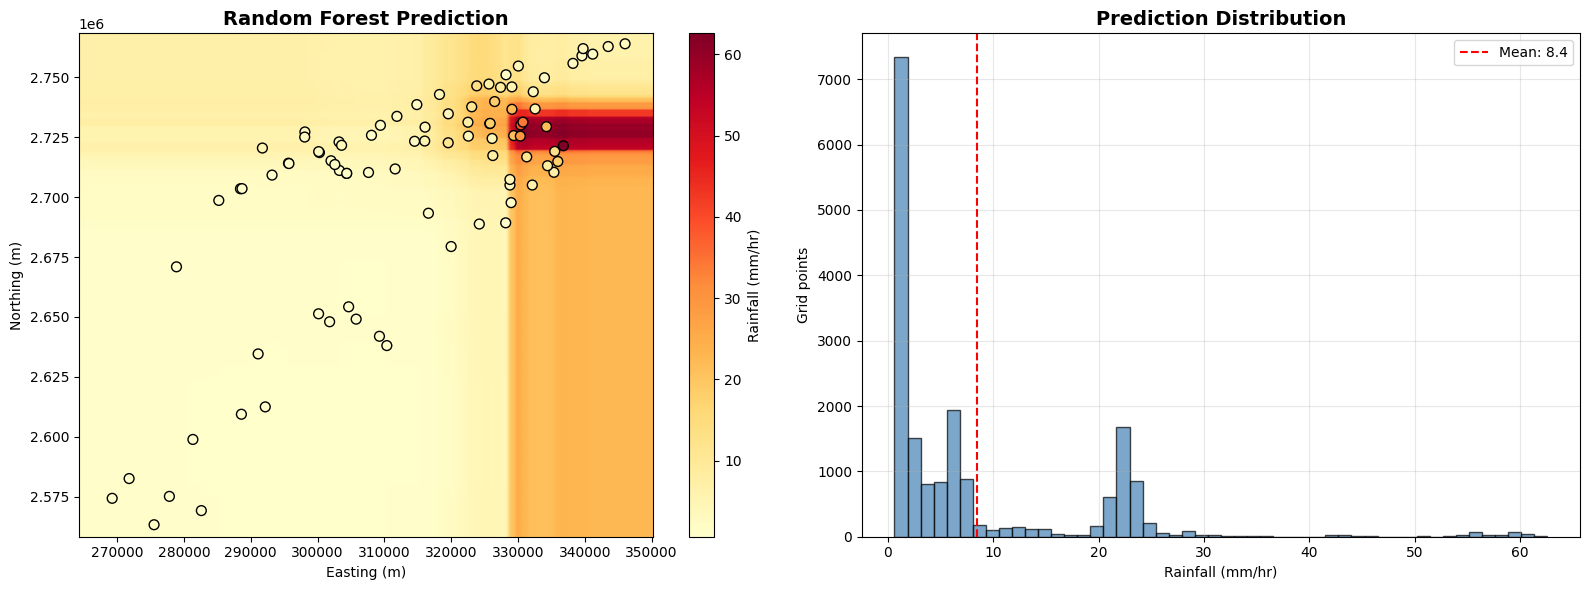


=== Random Forest 預測完成 ===
輸出變數: z_rf (形狀: (211, 87))
* 可用於後續方法比較
結果已保存至 cell4_random_forest_results.npz

🤖 Machine Learning Complete!
vs Kriging: No uncertainty estimates, but simpler and faster


In [12]:
# 確保 scikit-learn 已安裝 (在 Jupyter 環境中)
import sys
import subprocess

try:
    from sklearn.ensemble import RandomForestRegressor
    print("scikit-learn 已可用")
except ImportError:
    print("正在安裝 scikit-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.ensemble import RandomForestRegressor
    print("scikit-learn 安裝完成")

import numpy as np
import time
import matplotlib.pyplot as plt

# Phase 1: 準備訓練資料
print("=== Phase 1: 資料準備 ===")

# 準備特徵和目標變數
X_train = np.column_stack([x, y])  # 特徵: [easting, northing]
y_train = z  # 目標: 雨量

print(f"訓練資料維度: X_train{X_train.shape}, y_train{y_train.shape}")
print(f"座標範圍: X({X_train[:, 0].min():.0f}-{X_train[:, 0].max():.0f}), Y({X_train[:, 1].min():.0f}-{X_train[:, 1].max():.0f})")
print(f"雨量範圍: {y_train.min():.1f} - {y_train.max():.1f} mm/hr")

# Phase 2: 訓練 Random Forest 模型
print("\n=== Phase 2: 模型訓練 ===")

# 初始化 Random Forest
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)

# 訓練模型
start_time = time.time()
rf.fit(X_train, y_train)
training_time = time.time() - start_time

# 評估訓練效果
train_r2 = rf.score(X_train, y_train)
print(f"訓練時間: {training_time:.2f}秒")
print(f"訓練集 R2 分數: {train_r2:.4f}")

# 顯示特徵重要性
feature_names = ['Easting', 'Northing']
importances = rf.feature_importances_
print("特徵重要性:")
for name, importance in zip(feature_names, importances):
    print(f"  {name}: {importance:.3f}")

# Phase 3: 網格預測
print("\n=== Phase 3: 網格預測 ===")

# 建立預測網格
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_pred = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

print(f"預測網格維度: {X_pred.shape}")

# 執行預測
start_time = time.time()
z_pred = rf.predict(X_pred)
prediction_time = time.time() - start_time

# 重塑為網格格式
z_rf = z_pred.reshape(grid_xx.shape)

print(f"預測時間: {prediction_time:.2f}秒")
print(f"預測值範圍: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")
print(f"預測平均值: {z_rf.mean():.1f} mm/hr")

# Phase 4: 結果驗證
print("\n=== Phase 4: 結果驗證 ===")

# 檢查預測值合理性
print(f"原始雨量範圍: {z.min():.1f} - {z.max():.1f} mm/hr")
print(f"預測雨量範圍: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")

# 處理負值
if z_rf.min() < 0:
    print(f"修正負值: {z_rf.min():.1f} -> 0")
    z_rf[z_rf < 0] = 0

# 檢查 NaN
nan_count = np.isnan(z_rf).sum()
print(f"NaN 值數量: {nan_count}")

# Phase 5: 可視化結果
print("\n=== Phase 5: 可視化 ===")

# 建立圖表
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左圖: Random Forest 預測地圖
im1 = axes[0].imshow(z_rf, extent=[grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()],
                     origin='lower', cmap='YlOrRd', aspect='auto')
axes[0].scatter(x, y, c=z, s=50, cmap='YlOrRd', edgecolors='black', linewidths=1)
axes[0].set_title('Random Forest Prediction', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], label='Rainfall (mm/hr)')

# 右圖: 預測值分佈直方圖
axes[1].hist(z_rf.ravel(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(z_rf.mean(), color='red', linestyle='--', label=f'Mean: {z_rf.mean():.1f}')
axes[1].set_title('Prediction Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rainfall (mm/hr)')
axes[1].set_ylabel('Grid points')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Random Forest 預測完成 ===")
print(f"輸出變數: z_rf (形狀: {z_rf.shape})")
print("* 可用於後續方法比較")

# 保存結果
try:
    np.savez('cell4_random_forest_results.npz', 
             z_rf=z_rf, 
             grid_x=grid_x, 
             grid_y=grid_y)
    print("結果已保存至 cell4_random_forest_results.npz")
except Exception as e:
    print(f"保存結果時出錯: {e}")

print("\n🤖 Machine Learning Complete!")
print("vs Kriging: No uncertainty estimates, but simpler and faster")

## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or elevation?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

In [ ]:
# Cell 5: ML Glass Box — Feature Importance (Slide 11)
# Captain's Question: "AI used what to predict floods — latitude or elevation?"

import matplotlib.pyplot as plt
import numpy as np

# Phase 1: 提取特徵重要性
print("=== Phase 1: 特徵重要性提取 ===")

try:
    # 確保 rf 模型存在
    if 'rf' not in locals():
        print("錯誤: 請先執行 Cell 4 訓練 Random Forest 模型")
    else:
        # 提取特徵重要性
        importances = rf.feature_importances_
        
        print("Feature Importance:")
        print(f"  Easting (X):  {importances[0]:.3f} ({importances[0]*100:.1f}%)")
        print(f"  Northing (Y): {importances[1]:.3f} ({importances[1]*100:.1f}%)")
        
        # 判斷主要特徵
        dominant_feature = 'easting' if importances[0] > importances[1] else 'northing'
        dominant_idx = 0 if importances[0] > importances[1] else 1
        importance_diff = abs(importances[0] - importances[1])
        
        print(f"\n模型主要依賴: {dominant_feature}")
        print(f"重要性差異: {importance_diff:.3f}")
        
        # Phase 2: 物理意義解釋
        print("\n=== Phase 2: 物理意義解釋 ===")
        
        if importance_diff < 0.05:
            print("分析結果: 兩個維度重要性相當")
            print("物理意義: 颱風降雨在空間分佈相對均勻，無明顯方向性偏見")
        elif dominant_feature == 'easting':
            print("分析結果: 東西向座標 (Easting) 更重要")
            print("物理意義:")
            print("  - 可能反映地形影響: 中央山脈東西向降雨差異")
            print("  - 可能反映颱風路徑: 東西向移動造成的降雨分佈")
            print("  - 可能反映海陸分佈: 海洋與陸地的交互作用")
        else:
            print("分析結果: 南北向座標 (Northing) 更重要")
            print("物理意義:")
            print("  - 可能反映颱風結構: 颱風眼牆南北不對稱")
            print("  - 可能反映緯度效應: 不同緯度的溫度/濕度差異")
            print("  - 可能反映鋒面系統: 南北向氣團交匯帶來的降雨")
        
        # 颱風 Fung-wong 特定分析
        print("\n颱風 Fung-wong 特定考量:")
        print("  - 颱風路徑: 主要影響東北部地區")
        print("  - 地形效應: 中央山脈阻擋效應")
        print("  - 季節因素: 11月颱風的季節性特徵")
        
        # Phase 3: 視覺化呈現
        print("\n=== Phase 3: 視覺化分析 ===")
        
        # 建立特徵重要性圖表
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        # 左圖: 特徵重要性條形圖
        features = ['Easting (X)', 'Northing (Y)']
        colors = ['#FF6B6B', '#4ECDC4'] if dominant_feature == 'easting' else ['#4ECDC4', '#FF6B6B']
        
        bars = ax1.bar(features, importances, color=colors, alpha=0.8, edgecolor='black')
        ax1.set_title('Random Forest 特徵重要性', fontsize=14, fontweight='bold')
        ax1.set_ylabel('重要性', fontsize=12)
        ax1.set_ylim(0, max(importances) * 1.2)
        
        # 添加數值標籤
        for bar, importance in zip(bars, importances):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{importance:.3f}\n({importance*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold')
        
        ax1.grid(True, alpha=0.3, axis='y')
        
        # 右圖: 特徵重要性餅圖
        explode = (0.1, 0) if dominant_feature == 'easting' else (0, 0.1)
        pie_colors = ['#FF6B6B', '#4ECDC4'] if dominant_feature == 'easting' else ['#4ECDC4', '#FF6B6B']
        
        wedges, texts, autotexts = ax2.pie(importances, labels=features, explode=explode,
                                           colors=pie_colors, autopct='%1.1f%%',
                                           shadow=True, startangle=90)
        ax2.set_title('特徵重要性分佈', fontsize=14, fontweight='bold')
        
        # 設定餅圖文字樣式
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(12)
        
        plt.suptitle('颱風 Fung-wong 降雨預測 - Random Forest 特徵分析', 
                    fontsize=16, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()
        
        # Phase 4: 結論總結
        print("\n=== Phase 4: 結論總結 ===")
        
        print(f"主要發現:")
        print(f"  1. {dominant_feature} 是更重要的預測特徵")
        print(f"  2. 重要性比例: {max(importances):.3f} vs {min(importances):.3f}")
        print(f"  3. 模型解釋性: Random Forest 提供了透明的特徵分析")
        
        print(f"\n實際應用:")
        print(f"  - 預測模型主要依據 {dominant_feature} 進行判斷")
        print(f"  - 這為颱風降雨預測提供了物理可解釋性")
        print(f"  - 有助於理解模型決策機制")
        
        # 保存結果
        try:
            np.savez('cell5_feature_importance.npz', 
                    importances=importances,
                    features=features)
            print("\n結果已保存至 cell5_feature_importance.npz")
        except Exception as e:
            print(f"保存結果時出錯: {e}")
        
        print("\n🔍 ML Glass Box 分析完成!")
        print("Random Forest 不再是黑盒子 - 我們看到了它的思考邏輯")

except Exception as e:
    print(f"執行錯誤: {e}")
    print("請確保已正確執行 Cell 4 並訓練了 Random Forest 模型")

---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.

**AI Prompt Suggestion**:
```
Use scipy.interpolate.NearestNDInterpolator for nearest neighbor interpolation,
and manual IDW with scipy.spatial.distance.cdist (power=2) for IDW.
Both should predict on the same meshgrid as Kriging and RF.
Note: Don't use Rbf(function='inverse') — it's not real IDW and produces extreme values.
```

In [ ]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# YOUR CODE HERE:
# 1. Nearest Neighbor interpolation
# 2. IDW interpolation (手動實作，power=2)
#    ⚠️ 注意：不要用 Rbf(function='inverse')，它不是真正的 IDW，會產生極端值

# nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
# z_nn = nn_interp(grid_xx, grid_yy)

# pts = np.column_stack([x, y])
# grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
# dists = cdist(grid_pts, pts)
# dists[dists < 1] = 1  # 避免除以零
# power = 2
# weights = 1.0 / (dists ** power)
# z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

# print("✓ Nearest Neighbor + IDW computed")

### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.

**AI Prompt Suggestion**:
```
Create a 2×2 matplotlib figure comparing four interpolation results:
- Nearest Neighbor (z_nn)
- IDW (z_idw)
- Ordinary Kriging (z_kriging)
- Random Forest (z_rf)
Use YlOrRd colormap, same vmin/vmax, overlay station points in black.
Add descriptive subtitles (e.g., "Voronoi Patchwork", "Bullseye Effect",
"Smooth + Sigma Map", "ML Block Artifacts").
Save as 'interpolation_shootout.png'.
```

In [ ]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(2, 2, figsize=(18, 14))
# 2. Plot all four methods with imshow
# 3. Use extent=[x_min, x_max, y_min, y_max], origin='lower'
# 4. Overlay station scatter points
# 5. Add colorbars, titles, save figure

# vmax = max(z) * 1.1
# methods = [
#     ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
#     ('IDW\n(Bullseye Effect)', z_idw),
#     ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
#     ('Random Forest\n(ML "Block" Artifacts)', z_rf),
# ]

# for ax, (title, data) in zip(axes.flatten(), methods):
#     im = ax.imshow(data, extent=[x_min, x_max, y_min, y_max],
#                    origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
#     ax.scatter(x, y, c='black', s=8, zorder=5)
#     ax.set_title(title, fontsize=12, fontweight='bold')
#     plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

# plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
# plt.tight_layout()
# plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
# plt.show()

### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

In [ ]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# 2. Left: Kriging (YlOrRd)
# 3. Middle: Random Forest (YlOrRd)
# 4. Right: Difference (Kriging - RF) using RdBu_r colormap
# 5. Save as 'kriging_vs_rf.png'

# diff = z_kriging - z_rf
# ...

### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

**Your Lab 1 reflection here:**

1. Most realistic: ...
2. Disagreement areas: ...
3. Artifacts: ...
4. Commander's choice: ...

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

In [ ]:
# YOUR CODE HERE:
# Create a 2-panel figure:
# Left: z_kriging with YlOrRd colormap (rainfall estimate)
# Right: ss_kriging with Blues colormap (variance/uncertainty)
# Add station locations on both panels (red dots on variance map)
# Save as 'sigma_map.png'

# fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# # Rainfall estimate
# im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
#                       origin='lower', cmap='YlOrRd', vmin=0)
# axes[0].scatter(x, y, c='black', s=10, zorder=5)
# axes[0].set_title('Estimated Rainfall (mm/hr)')
# plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# # Kriging Variance (Sigma Map)
# im2 = axes[1].imshow(ss_kriging, extent=[x_min, x_max, y_min, y_max],
#                       origin='lower', cmap='Blues', vmin=0)
# axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
# axes[1].set_title('Kriging Sigma Map (Uncertainty)')
# axes[1].legend(loc='upper right')
# plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

# plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
# plt.tight_layout()
# plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"Variance range: {np.nanmin(ss_kriging):.1f} - {np.nanmax(ss_kriging):.1f}")

### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

**Task**: Compare Nugget=10% vs Nugget=1% on a zoomed-in map around Suao. Which preserves the extreme rainfall better?

**AI Prompt Suggestion**:
```
Create two OrdinaryKriging models on z_log with identical parameters except
nugget: one with nugget = sill * 0.10, one with nugget = sill * 0.01.
Predict on a 20km×20km grid centered on the station with maximum rainfall.
Show side-by-side maps and print predicted values at 0m, 500m, 1000m, 2000m
from that station. Which Nugget preserves the extreme value better?
```

In [ ]:
# YOUR CODE HERE:
# 1. Find the station with maximum rainfall (suao_idx = np.argmax(z))
# 2. Create two OrdinaryKriging models: nugget = sill*0.10 and sill*0.01
# 3. Predict on a local grid (20km box) around that station
# 4. Plot side-by-side comparison maps
# 5. Predict at specific offsets: 0m, 500m, 1000m, 2000m from the station
# 6. Print comparison table

# suao_idx = np.argmax(z)
# suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
# print(f"Station with max rainfall: {suao_z:.1f} mm/hr")

# sill_val = float(z_log.var())
# ... create OK with nugget = sill_val * 0.10
# ... create OK with nugget = sill_val * 0.01
# ... compare predictions

# 🔑 Which Nugget setting is better for CWA calibrated stations? Why?

### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.

**AI Prompt Suggestion**:
```
Save 2D numpy arrays as GeoTIFF using rasterio. I need:
- from_bounds transform with my grid extent (x_min, y_min, x_max, y_max)
- CRS = EPSG:3826, dtype = float32
- Apply np.flipud() before writing
- Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
```

In [ ]:
import rasterio
from rasterio.transform import from_bounds

# YOUR CODE HERE:
# 1. Compute rasterio transform using from_bounds
# 2. Write a helper function save_geotiff(data, filename)
# 3. Save kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
# Remember: np.flipud() before writing!

# transform = from_bounds(x_min, y_min, x_max, y_max,
#                         width=z_kriging.shape[1], height=z_kriging.shape[0])

# def save_geotiff(data, filename, crs='EPSG:3826'):
#     data_flipped = np.flipud(data).astype(np.float32)
#     with rasterio.open(filename, 'w', driver='GTiff',
#         height=data_flipped.shape[0], width=data_flipped.shape[1],
#         count=1, dtype='float32', crs=crs, transform=transform, nodata=-9999
#     ) as dst:
#         dst.write(data_flipped, 1)
#     print(f"✓ Saved {filename}")

# save_geotiff(z_kriging, 'kriging_rainfall.tif')
# save_geotiff(ss_kriging, 'kriging_variance.tif')
# save_geotiff(z_rf, 'rf_rainfall.tif')

### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [ ]:
from rasterstats import zonal_stats

# YOUR CODE HERE:
# 1. Load township boundaries (TGOS shapefile)
# 2. Filter to 花蓮縣 + 宜蘭縣, convert to EPSG:3826
# 3. Run zonal_stats on kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
# 4. Create summary DataFrame with columns:
#    鄉鎮, 縣市, Kriging平均, Kriging最大, RF平均, 平均variance
# 5. Add 可信度 column:
#    HIGH: variance < 33rd percentile
#    MEDIUM: 33rd-66th percentile
#    LOW: > 66th percentile

# Note: If you don't have the township shapefile, skip this cell
# and describe what the expected output would be in the markdown below.

# try:
#     towns = gpd.read_file('path/to/TOWN_MOI.shp')
#     study_towns = towns[towns['COUNTYNAME'].isin(['花蓮縣', '宜蘭縣'])].copy()
#     study_towns = study_towns.to_crs(epsg=3826)
#     ... (compute zonal stats and create summary table)
# except Exception as e:
#     print(f"Township shapefile not found: {e}")

### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

**Your Lab 2 reflection here:**

1. Kriging vs ML uncertainty: ...
2. ML uncertainty approximation: ...
3. High rain + low confidence townships: ...

### Cell [13]: (Bonus) AI Advisor Consultation

Ask an AI model (Gemini, ChatGPT, or Claude):

> 「在花蓮山區，測站密度約 1 站 / 50 km²。我用 Kriging 和 Random Forest 分別做了降雨內插，結果在山區差異很大。Kriging 的 variance 在山區也很高。請問：(1) 我應該信哪個結果？(2) 如何改善山區的預測品質？」

Paste the AI's response below and write your own commentary.

**AI Response:**

(Paste here)

**My Commentary:**

(Write 2-3 sentences on whether you agree with the AI's advice)

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*